# 🌞 Next-Day Solar Irradiance Forecasting — Pipeline v3
### Study Location: RUET, Rajshahi, Bangladesh (24.3641°N, 88.63°E)
**Data Source:** NASA POWER Daily Dataset (2011–2025)  
**Target Variable:** GHI(t+1) — Next-Day Global Horizontal Irradiance  
**Train Period:** 2011–2022 | **Test Period:** 2023–2025

---
### Changes in v3 over v1:
- ✅ **Month feature removed** — redundant with `sin_doy` / `cos_doy` cyclic encoding
- ✅ **Weather lag features added** — `Temperature_lag1`, `Humidity_lag1`, `WindSpeed_lag1`, `Precipitation_lag1`
- ✅ **RF & XGBoost hyperparameter tuning** via `RandomizedSearchCV` + `TimeSeriesSplit`
- ✅ **SVR removed from stacking ensemble** — retained as standalone model only
- ✅ **File upload** via `files.upload()` — no Google Drive path dependency
- ✅ **Auto-download** of all results as a ZIP at the end
- ✅ **300 DPI figures** with tight bounding box (set globally in rcParams)
---

## 📦 Section 1: Environment Setup & Library Imports

In [ ]:
# Install packages not pre-installed in Colab
!pip install xgboost shap --quiet

import os, io, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats

# Scikit-learn
from sklearn.linear_model    import LinearRegression, Ridge
from sklearn.svm             import SVR
from sklearn.ensemble        import RandomForestRegressor, StackingRegressor
from sklearn.preprocessing   import StandardScaler
from sklearn.pipeline        import Pipeline
from sklearn.model_selection import (TimeSeriesSplit, RandomizedSearchCV,
                                      cross_val_score)
from sklearn.metrics         import mean_absolute_error, mean_squared_error, r2_score

# XGBoost & SHAP
import xgboost as xgb
import shap

warnings.filterwarnings('ignore')
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Publication-quality plot style
# savefig.dpi and savefig.bbox apply globally to every plt.savefig() call
plt.rcParams.update({
    'font.family'      : 'DejaVu Sans',
    'font.size'        : 11,
    'axes.titlesize'   : 13,
    'axes.labelsize'   : 12,
    'xtick.labelsize'  : 10,
    'ytick.labelsize'  : 10,
    'legend.fontsize'  : 10,
    'figure.dpi'       : 120,
    'savefig.dpi'      : 300,
    'savefig.bbox'     : 'tight',
    'axes.spines.top'  : False,
    'axes.spines.right': False,
})

PALETTE = ['#2E86AB','#E84855','#3BB273','#F18F01','#7B2D8B','#FF6B6B','#1B998B']
SEASON_COLORS = {
    'Winter'      : '#2E86AB',
    'Pre-Monsoon' : '#F18F01',
    'Monsoon'     : '#E84855',
    'Post-Monsoon': '#3BB273',
}

# Output folder inside Colab runtime (downloaded as ZIP at the end)
OUTPUT_DIR = '/content/solar_outputs_v3'
os.makedirs(OUTPUT_DIR, exist_ok=True)

print('✓ All libraries imported.')
print(f'  XGBoost : {xgb.__version__}')
print(f'  SHAP    : {shap.__version__}')
print(f'  Pandas  : {pd.__version__}')

✓ All libraries imported.
  XGBoost : 3.2.0
  SHAP    : 0.51.0
  Pandas  : 2.2.2


## 📂 Section 2: Upload & Load Dataset

In [ ]:
# Upload your NASA POWER CSV directly from your computer.
# A 'Choose Files' button will appear — select the CSV file.
from google.colab import files

uploaded  = files.upload()
filename  = list(uploaded.keys())[0]
raw_bytes = io.BytesIO(uploaded[filename])

# Auto-detect the NASA POWER header row (line starting with 'YEAR')
header_row = None
raw_bytes.seek(0)
for idx, line in enumerate(raw_bytes):
    if line.decode('utf-8').startswith('YEAR'):
        header_row = idx
        break

# Load CSV, skipping NASA metadata lines above the column header
raw_bytes.seek(0)
df_raw = pd.read_csv(raw_bytes, skiprows=header_row)

print(f'✓ Loaded : {filename}')
print(f'  Shape  : {df_raw.shape}')
print(f'  Columns: {list(df_raw.columns)}')
print(df_raw.head())

Saving POWER_Point_Daily_20110101_20251231_024d36N_088d63E_UTC.csv to POWER_Point_Daily_20110101_20251231_024d36N_088d63E_UTC.csv
✓ Loaded : POWER_Point_Daily_20110101_20251231_024d36N_088d63E_UTC.csv
  Shape  : (5479, 8)
  Columns: ['YEAR', 'MO', 'DY', 'ALLSKY_SFC_SW_DWN', 'WS2M', 'T2M', 'RH2M', 'PRECTOTCORR']
   YEAR  MO  DY  ALLSKY_SFC_SW_DWN  WS2M    T2M   RH2M  PRECTOTCORR
0  2011   1   1             2.0246  1.25  16.43  78.82         0.49
1  2011   1   2             3.5866  1.77  14.99  56.22         0.00
2  2011   1   3             3.1910  1.52  14.70  61.12         0.00
3  2011   1   4             3.2753  2.10  14.79  67.34         0.00
4  2011   1   5             3.4990  1.99  14.41  62.50         0.00


In [ ]:
# Build DatetimeIndex and rename columns to readable names
df = df_raw.copy()
df['Date'] = pd.to_datetime(
    df[['YEAR','MO','DY']].rename(columns={'YEAR':'year','MO':'month','DY':'day'})
)
df = df.drop(columns=['YEAR','MO','DY']).set_index('Date').sort_index()

df = df.rename(columns={
    'ALLSKY_SFC_SW_DWN': 'GHI',
    'T2M'              : 'Temperature',
    'RH2M'             : 'Humidity',
    'WS2M'             : 'WindSpeed',
    'PRECTOTCORR'      : 'Precipitation',
})

print('✓ DatetimeIndex built and columns renamed.')
print(f'  Date range : {df.index[0].date()} → {df.index[-1].date()}')
print(f'  Shape      : {df.shape}')
print(f'  Columns    : {list(df.columns)}')
display(df.head())

✓ DatetimeIndex built and columns renamed.
  Date range : 2011-01-01 → 2025-12-31
  Shape      : (5479, 5)
  Columns    : ['GHI', 'WindSpeed', 'Temperature', 'Humidity', 'Precipitation']


,GHI,WindSpeed,Temperature,Humidity,Precipitation
Date,,,,,
2011-01-01,2.0246,1.25,16.43,78.82,0.49
2011-01-02,3.5866,1.77,14.99,56.22,0.00
2011-01-03,3.1910,1.52,14.70,61.12,0.00
2011-01-04,3.2753,2.10,14.79,67.34,0.00
2011-01-05,3.4990,1.99,14.41,62.50,0.00


In [ ]:
# ── Build DatetimeIndex & rename columns ─────────────────────────────────
df = df_raw.copy()
df['Date'] = pd.to_datetime(
    df[['YEAR', 'MO', 'DY']].rename(columns={'YEAR': 'year', 'MO': 'month', 'DY': 'day'})
)
df = df.drop(columns=['YEAR', 'MO', 'DY']).set_index('Date').sort_index()

df = df.rename(columns={
    'ALLSKY_SFC_SW_DWN': 'GHI',
    'T2M'              : 'Temperature',
    'RH2M'             : 'Humidity',
    'WS2M'             : 'WindSpeed',
    'PRECTOTCORR'      : 'Precipitation',
})

print('Dataset loaded and indexed by Date.')
print(f'Date range : {df.index[0].date()} → {df.index[-1].date()}')
print(f'Shape      : {df.shape}')
print('\nFirst 5 rows:')
display(df.head())

Dataset loaded and indexed by Date.
Date range : 2011-01-01 → 2025-12-31
Shape      : (5479, 5)

First 5 rows:


,GHI,WindSpeed,Temperature,Humidity,Precipitation
Date,,,,,
2011-01-01,2.0246,1.25,16.43,78.82,0.49
2011-01-02,3.5866,1.77,14.99,56.22,0.00
2011-01-03,3.1910,1.52,14.70,61.12,0.00
2011-01-04,3.2753,2.10,14.79,67.34,0.00
2011-01-05,3.4990,1.99,14.41,62.50,0.00


## 🔍 Section 3: Exploratory Data Analysis (EDA)

In [ ]:
# ─────────────────────────────────────────────────────────────────────────
# 3.1  Descriptive Statistics
# ─────────────────────────────────────────────────────────────────────────
print('=' * 60)
print('DESCRIPTIVE STATISTICS')
print('=' * 60)
desc = df.describe().T.round(4)
desc.index.name = 'Variable'
display(desc)

DESCRIPTIVE STATISTICS


,count,mean,std,min,25%,50%,75%,max
Variable,,,,,,,,
GHI,5479.0,4.3979,1.2677,0.5294,3.5244,4.428,5.3293,7.5473
WindSpeed,5479.0,1.8550,0.8387,0.2500,1.2500,1.650,2.2900,9.2500
Temperature,5479.0,25.6348,5.3036,9.9300,21.5100,27.710,29.3600,36.7700
Humidity,5479.0,70.5647,17.9998,12.7900,57.8750,76.440,85.2650,95.2800
Precipitation,5479.0,4.2894,8.3446,0.0000,0.0000,0.490,5.0700,90.2400


In [ ]:
# ─────────────────────────────────────────────────────────────────────────
# 3.2  Helper: Bangladesh seasonal labels
# ─────────────────────────────────────────────────────────────────────────
def get_season(month):
    """Map calendar month → Bangladesh meteorological season."""
    if month in [12, 1, 2]:    return 'Winter'
    if month in [3, 4, 5]:     return 'Pre-Monsoon'
    if month in [6, 7, 8, 9]:  return 'Monsoon'
    return 'Post-Monsoon'

SEASON_ORDER = ['Winter', 'Pre-Monsoon', 'Monsoon', 'Post-Monsoon']
df['Season'] = df.index.month.map(get_season)
df['Month']  = df.index.month
df['Year']   = df.index.year

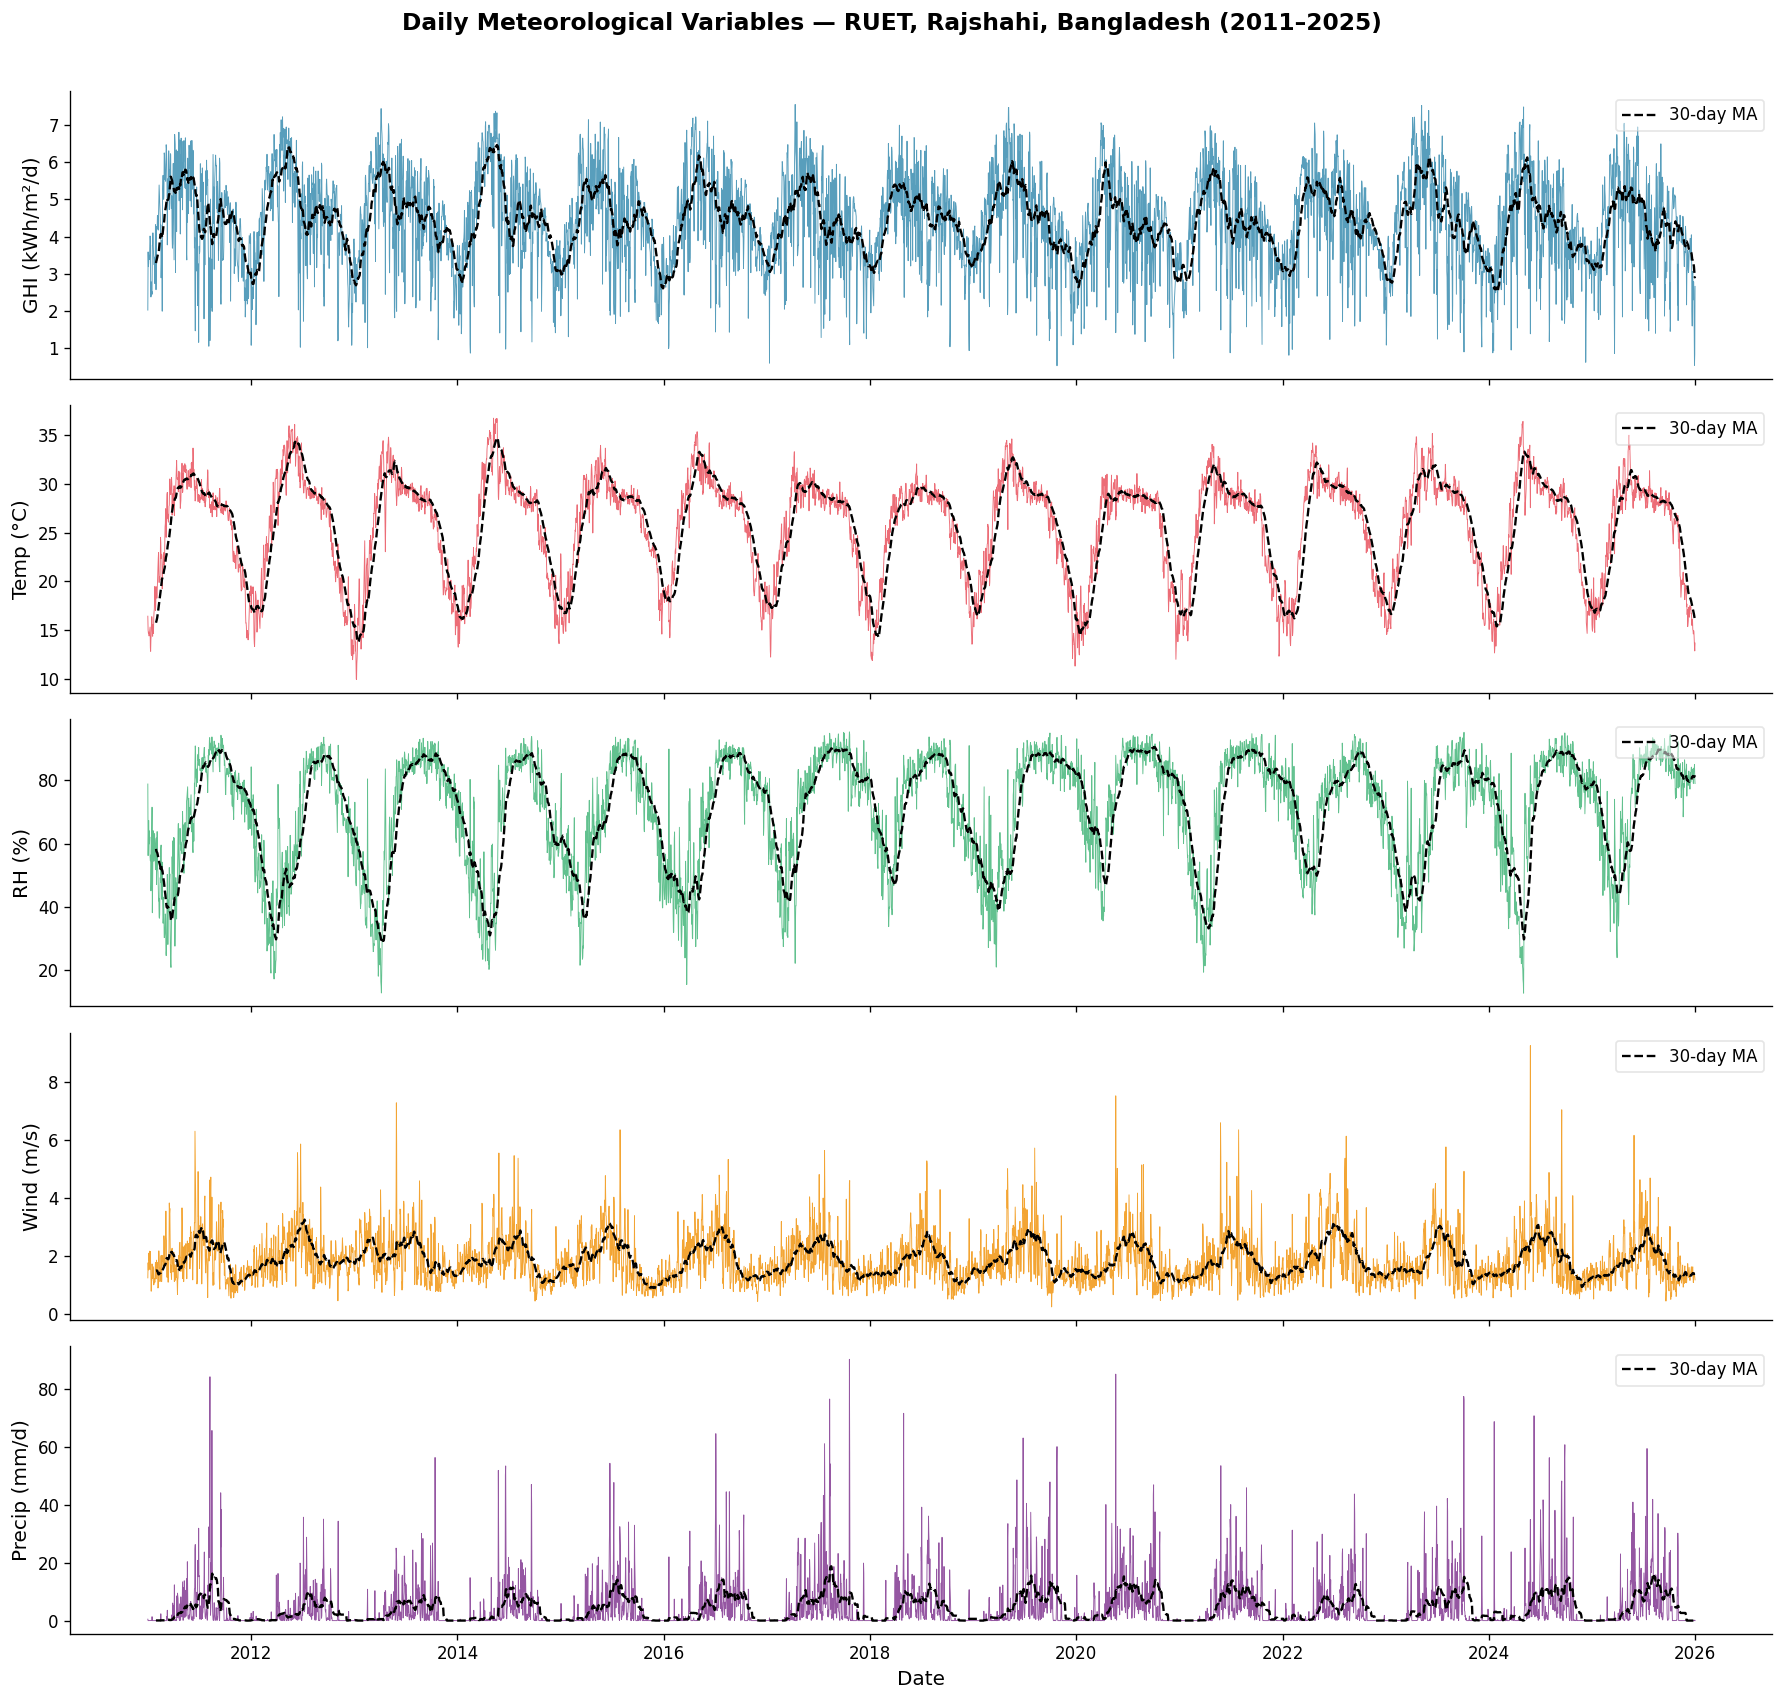

Saved → fig01_time_series_overview.png


In [ ]:
# ─────────────────────────────────────────────────────────────────────────
# 3.3  Figure 1 — Full Time-Series Overview
# ─────────────────────────────────────────────────────────────────────────
variables = ['GHI', 'Temperature', 'Humidity', 'WindSpeed', 'Precipitation']
ylabels   = ['GHI (kWh/m²/d)', 'Temp (°C)', 'RH (%)', 'Wind (m/s)', 'Precip (mm/d)']

fig, axes = plt.subplots(5, 1, figsize=(15, 14), sharex=True)
for ax, var, ylabel, color in zip(axes, variables, ylabels, PALETTE):
    ax.plot(df.index, df[var], color=color, linewidth=0.55, alpha=0.8)
    ax.plot(df.index, df[var].rolling(30).mean(), color='black',
            linewidth=1.4, linestyle='--', label='30-day MA')
    ax.set_ylabel(ylabel)
    ax.legend(loc='upper right', framealpha=0.5)

axes[-1].set_xlabel('Date')
fig.suptitle('Daily Meteorological Variables — RUET, Rajshahi, Bangladesh (2011–2025)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/fig01_time_series_overview.png')
plt.show()
print('Saved → fig01_time_series_overview.png')

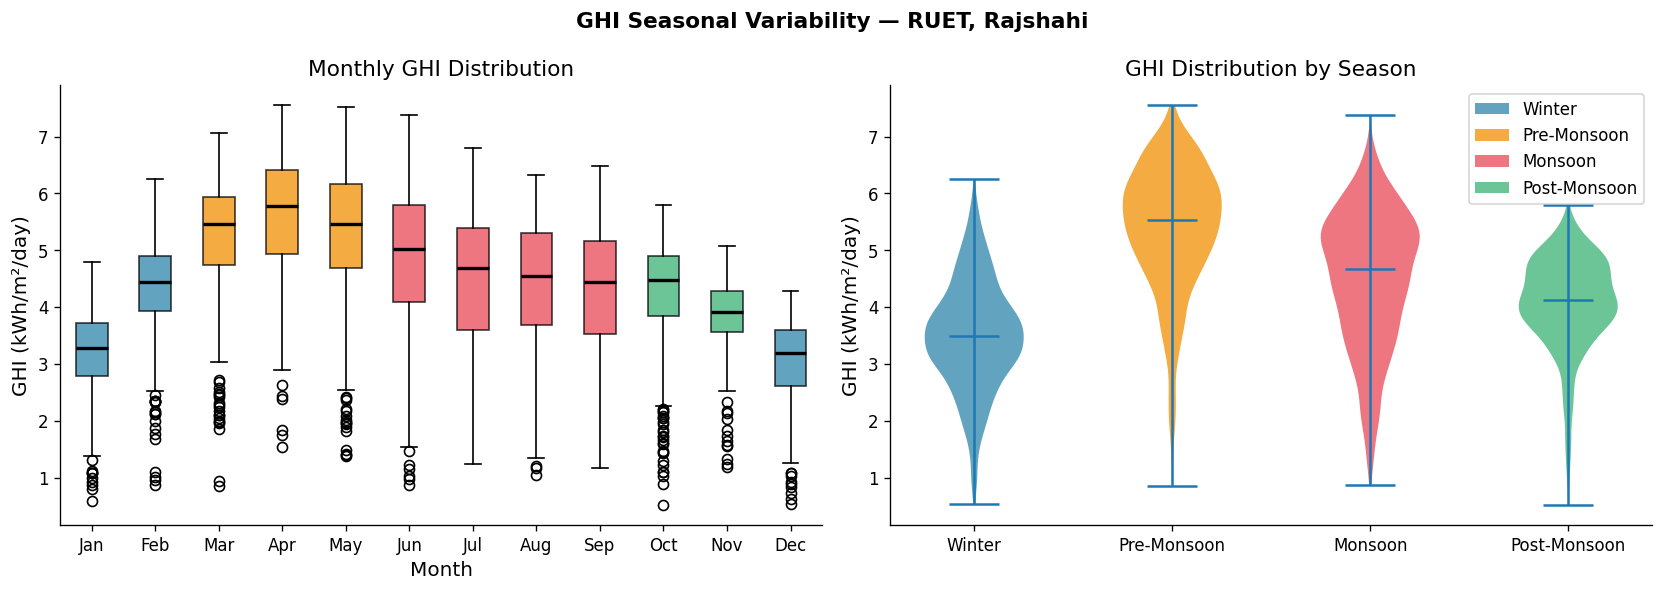

In [ ]:
# ─────────────────────────────────────────────────────────────────────────
# 3.4  Figure 2 — GHI Distribution: Monthly Box + Seasonal Violin
# ─────────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Monthly box plot
month_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
monthly_data = [df[df['Month'] == m]['GHI'].values for m in range(1, 13)]
bp = axes[0].boxplot(monthly_data, labels=month_labels, patch_artist=True, notch=False,
                     medianprops=dict(color='black', linewidth=2))
for patch, m in zip(bp['boxes'], range(1, 13)):
    patch.set_facecolor(SEASON_COLORS[get_season(m)])
    patch.set_alpha(0.75)
axes[0].set_title('Monthly GHI Distribution')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('GHI (kWh/m²/day)')

# Seasonal violin plot
season_data = [df[df['Season'] == s]['GHI'].values for s in SEASON_ORDER]
parts = axes[1].violinplot(season_data, positions=range(4), showmedians=True)
for pc, s in zip(parts['bodies'], SEASON_ORDER):
    pc.set_facecolor(SEASON_COLORS[s])
    pc.set_alpha(0.75)
axes[1].set_xticks(range(4))
axes[1].set_xticklabels(SEASON_ORDER)
axes[1].set_title('GHI Distribution by Season')
axes[1].set_ylabel('GHI (kWh/m²/day)')

from matplotlib.patches import Patch
legend_patches = [Patch(facecolor=SEASON_COLORS[s], label=s, alpha=0.75) for s in SEASON_ORDER]
axes[1].legend(handles=legend_patches, loc='upper right')

plt.suptitle('GHI Seasonal Variability — RUET, Rajshahi', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/fig02_seasonal_ghi_distribution.png')
plt.show()

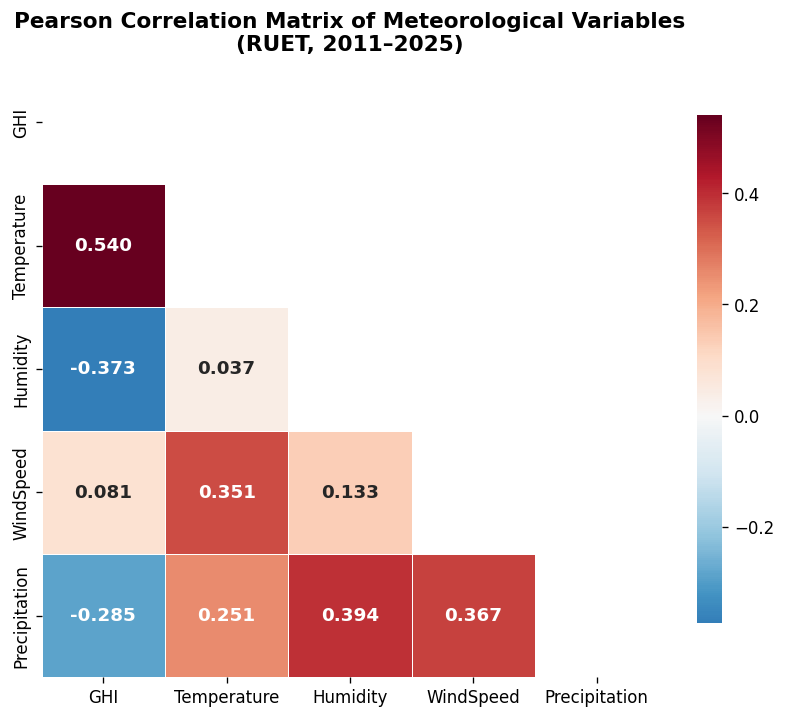

Correlation with GHI:
Temperature      0.5404
Humidity        -0.3731
Precipitation   -0.2848
WindSpeed        0.0812
Name: GHI, dtype: float64


In [ ]:
# ─────────────────────────────────────────────────────────────────────────
# 3.5  Figure 3 — Pearson Correlation Heatmap
# ─────────────────────────────────────────────────────────────────────────
numeric_cols = ['GHI', 'Temperature', 'Humidity', 'WindSpeed', 'Precipitation']
corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(7, 6))
mask = np.triu(np.ones_like(corr, dtype=bool))  # show lower triangle only
sns.heatmap(corr, annot=True, fmt='.3f', cmap='RdBu_r', center=0,
            mask=mask, square=True, linewidths=0.5,
            cbar_kws={'shrink': 0.8}, ax=ax, annot_kws={'size': 11, 'weight': 'bold'})
ax.set_title('Pearson Correlation Matrix of Meteorological Variables\n(RUET, 2011–2025)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/fig03_correlation_heatmap.png')
plt.show()

print('Correlation with GHI:')
print(corr['GHI'].drop('GHI').sort_values(key=abs, ascending=False).round(4))

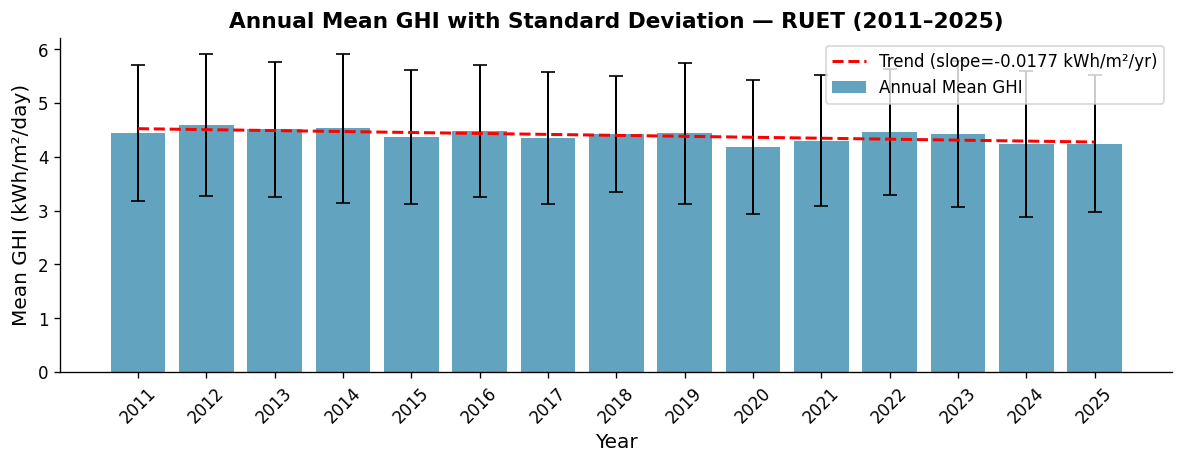

In [ ]:
# ─────────────────────────────────────────────────────────────────────────
# 3.6  Figure 4 — Annual Mean GHI Trend
# ─────────────────────────────────────────────────────────────────────────
annual = df.groupby('Year')['GHI'].agg(['mean', 'std']).reset_index()

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(annual['Year'], annual['mean'], yerr=annual['std'],
       color=PALETTE[0], alpha=0.75, capsize=4,
       error_kw={'linewidth': 1.2}, label='Annual Mean GHI')
z = np.polyfit(annual['Year'], annual['mean'], 1)
ax.plot(annual['Year'], np.poly1d(z)(annual['Year']),
        'r--', linewidth=1.8, label=f'Trend (slope={z[0]:.4f} kWh/m²/yr)')
ax.set_xlabel('Year')
ax.set_ylabel('Mean GHI (kWh/m²/day)')
ax.set_title('Annual Mean GHI with Standard Deviation — RUET (2011–2025)',
             fontsize=13, fontweight='bold')
ax.legend()
ax.set_xticks(annual['Year'])
ax.set_xticklabels(annual['Year'], rotation=45)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/fig04_annual_ghi_trend.png')
plt.show()

In [ ]:
# ─────────────────────────────────────────────────────────────────────────
# 3.7  Outlier Detection using IQR method
# ─────────────────────────────────────────────────────────────────────────
print('Outlier Detection (IQR method, threshold = 3×IQR):')
print('-' * 50)
outlier_summary = {}
for col in numeric_cols:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR    = Q3 - Q1
    lower, upper = Q1 - 3 * IQR, Q3 + 3 * IQR
    n_out  = ((df[col] < lower) | (df[col] > upper)).sum()
    outlier_summary[col] = {'Lower Bound': round(lower, 4),
                            'Upper Bound': round(upper, 4),
                            'Outlier Count': n_out,
                            'Outlier %': round(n_out / len(df) * 100, 3)}
display(pd.DataFrame(outlier_summary).T)

Outlier Detection (IQR method, threshold = 3×IQR):
--------------------------------------------------


,Lower Bound,Upper Bound,Outlier Count,Outlier %
GHI,-1.8903,10.744,0.0,0.000
Temperature,-2.0400,52.910,0.0,0.000
Humidity,-24.2950,167.435,0.0,0.000
WindSpeed,-1.8700,5.410,21.0,0.383
Precipitation,-15.2100,20.280,279.0,5.092


## 🧹 Section 4: Missing Value Handling

In [ ]:
# NASA POWER encodes missing/invalid data as -999.
# Replace → NaN → linear interpolation → edge fill.

fill_cols = ['GHI','Temperature','Humidity','WindSpeed','Precipitation']

# Report -999 counts
missing_count = (df[fill_cols] == -999).sum()
missing_pct   = (df[fill_cols] == -999).mean() * 100
print('Missing values encoded as -999:')
display(pd.DataFrame({'Count': missing_count, 'Percentage (%)': missing_pct.round(4)}))

# Replace -999 → NaN
df[fill_cols] = df[fill_cols].replace(-999, np.nan)

# Linear interpolation (preserves temporal continuity)
df[fill_cols] = df[fill_cols].interpolate(method='linear')

# Handle any leading/trailing NaNs
df[fill_cols] = df[fill_cols].bfill().ffill()

print(f'\nRemaining NaN after imputation: {df[fill_cols].isna().sum().sum()}')
print('✓ Missing value handling complete.')

Missing values encoded as -999:


,Count,Percentage (%)
GHI,0,0.0
Temperature,0,0.0
Humidity,0,0.0
WindSpeed,0,0.0
Precipitation,0,0.0



Remaining NaN after imputation: 0
✓ Missing value handling complete.


## ⚙️ Section 5: Feature Engineering (v3)

**Features in v3:**
- `GHI`, `GHI_lag1`, `GHI_lag2` — current and lagged GHI
- `GHI_roll7` — 7-day rolling mean of GHI
- `Temperature`, `Humidity`, `WindSpeed`, `Precipitation` — current-day weather
- `Temperature_lag1`, `Humidity_lag1`, `WindSpeed_lag1`, `Precipitation_lag1` — **weather lags [NEW]**
- `sin_doy`, `cos_doy` — cyclic seasonal encoding
- **Month removed** — redundant with sin/cos encoding

In [ ]:
# ── GHI lag features ────────────────────────────────────────────────────
df['GHI_lag1']  = df['GHI'].shift(1)   # GHI(t-1)
df['GHI_lag2']  = df['GHI'].shift(2)   # GHI(t-2)

# ── 7-day rolling mean (shift(1) anchors window at t-1, prevents leakage)
df['GHI_roll7'] = df['GHI'].shift(1).rolling(window=7).mean()

# ── Weather lag features [NEW] ───────────────────────────────────────────
# Weather has day-to-day autocorrelation.
# Yesterday's humidity and precipitation are especially predictive of
# tomorrow's GHI in monsoon-affected climates.
df['Temperature_lag1']   = df['Temperature'].shift(1)
df['Humidity_lag1']      = df['Humidity'].shift(1)
df['WindSpeed_lag1']     = df['WindSpeed'].shift(1)
df['Precipitation_lag1'] = df['Precipitation'].shift(1)

# ── Cyclic seasonal encoding (365.25 for leap-year continuity) ───────────
doy = df.index.dayofyear
df['sin_doy'] = np.sin(2 * np.pi * doy / 365.25)
df['cos_doy'] = np.cos(2 * np.pi * doy / 365.25)
# Note: Month feature is intentionally excluded — sin_doy/cos_doy already
# encode seasonality more precisely without artificial discontinuities.

# ── Target: GHI(t+1) ─────────────────────────────────────────────────────
df['GHI_target'] = df['GHI'].shift(-1)

# ── Drop rows with NaN from lag/rolling/target creation ──────────────────
df_model = df.dropna(subset=[
    'GHI_lag1', 'GHI_lag2', 'GHI_roll7',
    'Temperature_lag1', 'Humidity_lag1',
    'WindSpeed_lag1', 'Precipitation_lag1',
    'GHI_target'
]).copy()

print(f'Rows before feature engineering : {len(df)}')
print(f'Rows after  feature engineering : {len(df_model)}')
print(f'Date range  : {df_model.index[0].date()} → {df_model.index[-1].date()}')

Rows before feature engineering : 5479
Rows after  feature engineering : 5471
Date range  : 2011-01-08 → 2025-12-30


In [ ]:
# Final feature set (14 features — v3)
FEATURES = [
    # ── GHI features ──────────────────────────────────────────────────
    'GHI',                 # GHI(t)       — current-day irradiance
    'GHI_lag1',            # GHI(t-1)     — yesterday
    'GHI_lag2',            # GHI(t-2)     — two days ago
    'GHI_roll7',           # 7-day rolling mean
    # ── Current-day weather ───────────────────────────────────────────
    'Temperature',
    'Humidity',
    'WindSpeed',
    'Precipitation',
    # ── Weather lag features [NEW] ────────────────────────────────────
    'Temperature_lag1',
    'Humidity_lag1',
    'WindSpeed_lag1',
    'Precipitation_lag1',
    # ── Cyclic seasonal encoding ──────────────────────────────────────
    'sin_doy',
    'cos_doy',
    # Month intentionally excluded — redundant with sin/cos encoding
]
TARGET = 'GHI_target'

print(f'Feature set ({len(FEATURES)} features):')
for i, f in enumerate(FEATURES, 1):
    tag = '[NEW]' if 'lag1' in f and f != 'GHI_lag1' else ''
    print(f'  {i:2d}. {f:22s} {tag}')
print(f'\nTarget : {TARGET}')

Feature set (14 features):
   1. GHI                    
   2. GHI_lag1               
   3. GHI_lag2               
   4. GHI_roll7              
   5. Temperature            
   6. Humidity               
   7. WindSpeed              
   8. Precipitation          
   9. Temperature_lag1       [NEW]
  10. Humidity_lag1          [NEW]
  11. WindSpeed_lag1         [NEW]
  12. Precipitation_lag1     [NEW]
  13. sin_doy                
  14. cos_doy                

Target : GHI_target


## 📊 Section 6: Supervised Dataset Construction & Train/Test Split

In [ ]:
# ─────────────────────────────────────────────────────────────────────────
# Temporal split — NEVER shuffle time-series data
# Train: 2011–2022 | Test: 2023–2025
# ─────────────────────────────────────────────────────────────────────────
TRAIN_END  = '2022-12-31'
TEST_START = '2023-01-01'

train = df_model.loc[:TRAIN_END]
test  = df_model.loc[TEST_START:]

X_train = train[FEATURES].values
y_train = train[TARGET].values
X_test  = test[FEATURES].values
y_test  = test[TARGET].values

print('Temporal Train/Test Split:')
print(f'  Train: {train.index[0].date()} → {train.index[-1].date()} | {len(train):,} samples')
print(f'  Test : {test.index[0].date()}  → {test.index[-1].date()}  | {len(test):,} samples')
print(f'  Split ratio: {len(train)/len(df_model)*100:.1f}% / {len(test)/len(df_model)*100:.1f}%')

Temporal Train/Test Split:
  Train: 2011-01-08 → 2022-12-31 | 4,376 samples
  Test : 2023-01-01  → 2025-12-30  | 1,095 samples
  Split ratio: 80.0% / 20.0%


## 📏 Section 7: Evaluation Helper & Baseline Models

In [ ]:
# ─────────────────────────────────────────────────────────────────────────
# Centralised evaluation function — used for all models
# ─────────────────────────────────────────────────────────────────────────
def mape_score(y_true, y_pred, eps=0.1):
    """MAPE excluding near-zero GHI values (avoid division by ~0)."""
    mask = np.abs(y_true) > eps
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

def evaluate(name, y_true, y_pred):
    """Return a dict of all four evaluation metrics."""
    return {
        'Model': name,
        'MAE'  : round(float(mean_absolute_error(y_true, y_pred)), 4),
        'RMSE' : round(float(np.sqrt(mean_squared_error(y_true, y_pred))), 4),
        'MAPE' : round(float(mape_score(y_true, y_pred)), 4),
        'R²'   : round(float(r2_score(y_true, y_pred)), 4),
    }

# Storage for all model results and predictions
all_results  = []
predictions  = {}

# ─────────────────────────────────────────────────────────────────────────
# Baseline 1 — Persistence: GHI(t+1) = GHI(t)
# ─────────────────────────────────────────────────────────────────────────
ghi_idx   = FEATURES.index('GHI')
y_persist = X_test[:, ghi_idx]   # GHI(t) used as prediction for GHI(t+1)

res = evaluate('Persistence', y_test, y_persist)
all_results.append(res)
predictions['Persistence'] = y_persist
print('Baseline 1 — Persistence:', res)

# ─────────────────────────────────────────────────────────────────────────
# Baseline 2 — Climatological Mean (smoothed day-of-year mean from train)
# ─────────────────────────────────────────────────────────────────────────
train_tmp = train.copy()
train_tmp['DOY'] = train_tmp.index.dayofyear
doy_mean  = train_tmp.groupby('DOY')[TARGET].mean()
doy_smooth = doy_mean.rolling(7, center=True, min_periods=1).mean().to_dict()

y_clim = np.array([
    doy_smooth.get(d, doy_mean.iloc[np.argmin(np.abs(doy_mean.index - d))])
    for d in test.index.dayofyear
])

res = evaluate('Climatological Mean', y_test, y_clim)
all_results.append(res)
predictions['Climatological Mean'] = y_clim
print('Baseline 2 — Climatological Mean:', res)

Baseline 1 — Persistence: {'Model': 'Persistence', 'MAE': 0.729, 'RMSE': 1.0273, 'MAPE': 21.0901, 'R²': 0.4022}
Baseline 2 — Climatological Mean: {'Model': 'Climatological Mean', 'MAE': 0.8236, 'RMSE': 1.0852, 'MAPE': 27.008, 'R²': 0.3329}


## 🤖 Section 8: Machine Learning Models with TimeSeriesSplit CV

In [ ]:
# ─────────────────────────────────────────────────────────────────────────
# TimeSeriesSplit — used for ALL cross-validation during model evaluation.
# This preserves temporal ordering (no future data leaks into validation).
# ─────────────────────────────────────────────────────────────────────────
tscv = TimeSeriesSplit(n_splits=5)

def ts_cv_rmse(model, X, y):
    """Return mean RMSE across 5 time-series cross-validation folds."""
    scores = cross_val_score(model, X, y,
                             cv=tscv,
                             scoring='neg_root_mean_squared_error',
                             n_jobs=-1)
    return -scores.mean(), scores.std()

print('TimeSeriesSplit CV configured with 5 folds.')
print('Each fold respects temporal order — no data leakage.')

TimeSeriesSplit CV configured with 5 folds.
Each fold respects temporal order — no data leakage.


In [ ]:
# ─────────────────────────────────────────────────────────────────────────
# Model 1 — Linear Regression
# Requires StandardScaler (feature magnitudes differ widely)
# ─────────────────────────────────────────────────────────────────────────
lr_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  LinearRegression()),
])
lr_pipe.fit(X_train, y_train)
y_lr = lr_pipe.predict(X_test)

cv_rmse, cv_std = ts_cv_rmse(lr_pipe, X_train, y_train)
res = evaluate('Linear Regression', y_test, y_lr)
all_results.append(res)
predictions['Linear Regression'] = y_lr
print(f'Linear Regression  | Test: {res}  | CV RMSE: {cv_rmse:.4f} ± {cv_std:.4f}')

# Feature coefficients (after inverse-scaling to original units)
lr_coef = pd.Series(lr_pipe.named_steps['model'].coef_, index=FEATURES)
print('\nStandardised Coefficients (sorted by |magnitude|):')
print(lr_coef.sort_values(key=abs, ascending=False).round(4).to_string())

Linear Regression  | Test: {'Model': 'Linear Regression', 'MAE': 0.6568, 'RMSE': 0.8798, 'MAPE': 20.4346, 'R²': 0.5615}  | CV RMSE: 0.8522 ± 0.0263

Standardised Coefficients (sorted by |magnitude|):
Temperature_lag1      0.5414
GHI                   0.5396
Humidity             -0.4156
Temperature          -0.3691
Humidity_lag1         0.3403
Precipitation        -0.2021
Precipitation_lag1    0.1291
cos_doy              -0.1204
WindSpeed            -0.1149
sin_doy               0.1041
GHI_roll7             0.0846
WindSpeed_lag1        0.0646
GHI_lag2              0.0544
GHI_lag1              0.0403


In [ ]:
# ─────────────────────────────────────────────────────────────────────────
# Model 2 — Support Vector Regression (RBF kernel)
# Requires StandardScaler — SVR is highly sensitive to feature scale
# ─────────────────────────────────────────────────────────────────────────
svr_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  SVR(kernel='rbf', C=100, gamma=0.1, epsilon=0.1)),
])
svr_pipe.fit(X_train, y_train)
y_svr = svr_pipe.predict(X_test)

cv_rmse, cv_std = ts_cv_rmse(svr_pipe, X_train, y_train)
res = evaluate('SVR', y_test, y_svr)
all_results.append(res)
predictions['SVR'] = y_svr
print(f'SVR                | Test: {res}  | CV RMSE: {cv_rmse:.4f} ± {cv_std:.4f}')

SVR                | Test: {'Model': 'SVR', 'MAE': 0.7612, 'RMSE': 1.0538, 'MAPE': 23.0054, 'R²': 0.371}  | CV RMSE: 1.0613 ± 0.0658


In [ ]:
# ── Model 3: Random Forest with Hyperparameter Tuning ───────────────────
# RandomizedSearchCV with TimeSeriesSplit preserves temporal ordering
# during cross-validation — no future data leaks into validation folds.
print('Tuning Random Forest with RandomizedSearchCV (TimeSeriesSplit, 20 iterations)...')

rf_param_dist = {
    'n_estimators'     : [200, 300, 500],
    'max_depth'        : [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf' : [1, 2, 4],
    'max_features'     : ['sqrt', 'log2', 0.5],
}

rf_search = RandomizedSearchCV(
    RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1),
    rf_param_dist,
    n_iter       = 20,
    cv           = tscv,
    scoring      = 'neg_root_mean_squared_error',
    random_state = RANDOM_STATE,
    n_jobs       = -1,
    verbose      = 1,
)
rf_search.fit(X_train, y_train)

rf_model = rf_search.best_estimator_
y_rf     = rf_model.predict(X_test)

cv_rmse, cv_std = ts_cv_rmse(rf_model, X_train, y_train)
res = evaluate('Random Forest', y_test, y_rf)
all_results.append(res)
predictions['Random Forest'] = y_rf

print(f'\nBest RF params : {rf_search.best_params_}')
print(f'Random Forest  | Test: {res} | CV RMSE: {cv_rmse:.4f} ± {cv_std:.4f}')

rf_importance = pd.Series(
    rf_model.feature_importances_, index=FEATURES
).sort_values(ascending=False)
print('\nRF Feature Importances:')
print(rf_importance.round(4).to_string())

Tuning Random Forest with RandomizedSearchCV (TimeSeriesSplit, 20 iterations)...
Fitting 5 folds for each of 20 candidates, totalling 100 fits

Best RF params : {'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 0.5, 'max_depth': 20}
Random Forest  | Test: {'Model': 'Random Forest', 'MAE': 0.6278, 'RMSE': 0.8576, 'MAPE': 19.8735, 'R²': 0.5834} | CV RMSE: 0.8315 ± 0.0311

RF Feature Importances:
GHI                   0.3711
cos_doy               0.1005
GHI_lag1              0.0889
Precipitation         0.0649
sin_doy               0.0519
Humidity              0.0506
WindSpeed             0.0441
GHI_roll7             0.0420
Temperature           0.0410
Temperature_lag1      0.0370
GHI_lag2              0.0287
Humidity_lag1         0.0268
WindSpeed_lag1        0.0265
Precipitation_lag1    0.0260


In [ ]:
# ── Model 4: XGBoost with Hyperparameter Tuning ─────────────────────────
print('Tuning XGBoost with RandomizedSearchCV (TimeSeriesSplit, 30 iterations)...')

xgb_param_dist = {
    'n_estimators'    : [300, 500, 700],
    'learning_rate'   : [0.01, 0.03, 0.05, 0.1],
    'max_depth'       : [3, 4, 5, 6],
    'min_child_weight': [1, 3, 5],
    'subsample'       : [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9],
    'gamma'           : [0, 0.1, 0.2],
    'reg_alpha'       : [0, 0.1, 0.5],
    'reg_lambda'      : [0.5, 1.0, 2.0],
}

xgb_search = RandomizedSearchCV(
    xgb.XGBRegressor(random_state=RANDOM_STATE, n_jobs=-1, verbosity=0),
    xgb_param_dist,
    n_iter       = 30,
    cv           = tscv,
    scoring      = 'neg_root_mean_squared_error',
    random_state = RANDOM_STATE,
    n_jobs       = -1,
    verbose      = 1,
)
xgb_search.fit(X_train, y_train)

xgb_model = xgb_search.best_estimator_
y_xgb     = xgb_model.predict(X_test)

cv_rmse, cv_std = ts_cv_rmse(xgb_model, X_train, y_train)
res = evaluate('XGBoost', y_test, y_xgb)
all_results.append(res)
predictions['XGBoost'] = y_xgb

print(f'\nBest XGBoost params : {xgb_search.best_params_}')
print(f'XGBoost             | Test: {res} | CV RMSE: {cv_rmse:.4f} ± {cv_std:.4f}')

xgb_importance = pd.Series(
    xgb_model.feature_importances_, index=FEATURES
).sort_values(ascending=False)
print('\nXGBoost Feature Importances:')
print(xgb_importance.round(4).to_string())

Tuning XGBoost with RandomizedSearchCV (TimeSeriesSplit, 30 iterations)...
Fitting 5 folds for each of 30 candidates, totalling 150 fits

Best XGBoost params : {'subsample': 0.7, 'reg_lambda': 1.0, 'reg_alpha': 0.1, 'n_estimators': 700, 'min_child_weight': 5, 'max_depth': 4, 'learning_rate': 0.01, 'gamma': 0.1, 'colsample_bytree': 0.8}
XGBoost             | Test: {'Model': 'XGBoost', 'MAE': 0.6219, 'RMSE': 0.8458, 'MAPE': 19.5072, 'R²': 0.5948} | CV RMSE: 0.8251 ± 0.0311

XGBoost Feature Importances:
GHI                   0.4034
cos_doy               0.0887
GHI_lag1              0.0806
sin_doy               0.0725
Temperature_lag1      0.0549
Precipitation         0.0540
Humidity              0.0492
WindSpeed             0.0350
Temperature           0.0325
GHI_roll7             0.0324
Precipitation_lag1    0.0312
WindSpeed_lag1        0.0225
Humidity_lag1         0.0221
GHI_lag2              0.0211


## 🧩 Section 9: Stacking Ensemble (RF + XGBoost → Ridge)
> SVR is retained as a standalone comparison model only.
> It is excluded from the ensemble because its performance degrades
> when base-learner predictions are correlated (which RF and XGBoost predictions are).

In [ ]:
# ── Stacking Ensemble Design (v3) ───────────────────────────────────────
#
#  Level 0 — Base Learners : tuned Random Forest + tuned XGBoost
#  Level 1 — Meta Learner  : Ridge Regression
#
#  SVR is excluded from the ensemble (retained as standalone only).
#  Using tuned base learners from rf_search and xgb_search above.
#  Out-of-fold (OOF) predictions train the meta learner (cv=5).
# ─────────────────────────────────────────────────────────────────────────

base_estimators = [
    ('rf',  rf_search.best_estimator_),    # tuned Random Forest
    ('xgb', xgb_search.best_estimator_),   # tuned XGBoost
]

stacking_model = StackingRegressor(
    estimators      = base_estimators,
    final_estimator = Ridge(alpha=1.0),
    cv              = 5,
    n_jobs          = 1,
    passthrough     = False,
)

print('Training Stacking Ensemble (RF + XGBoost → Ridge)...')
stacking_model.fit(X_train, y_train)
y_stack = stacking_model.predict(X_test)

res = evaluate('Stacking Ensemble', y_test, y_stack)
all_results.append(res)
predictions['Stacking Ensemble'] = y_stack
print('✓ Stacking Ensemble trained.')
print(res)

Training Stacking Ensemble (RF + XGBoost → Ridge)...
✓ Stacking Ensemble trained.
{'Model': 'Stacking Ensemble', 'MAE': 0.6206, 'RMSE': 0.8454, 'MAPE': 19.469, 'R²': 0.5952}


## 📋 Section 10: Model Evaluation & Comparison

In [ ]:
# ─────────────────────────────────────────────────────────────────────────
# Overall results table
# ─────────────────────────────────────────────────────────────────────────
results_df = pd.DataFrame(all_results).set_index('Model')

# Highlight best per metric
def highlight_best(s):
    is_best = (s == s.min()) if s.name != 'R²' else (s == s.max())
    return ['font-weight: bold; background-color: #d4edda' if v else '' for v in is_best]

print('MODEL PERFORMANCE COMPARISON — Test Period (2023–2025)')
print('=' * 65)
display(results_df.style.apply(highlight_best))

# Improvement over persistence baseline
print('\nImprovement of Stacking Ensemble over Persistence Baseline:')
for m in ['MAE', 'RMSE', 'MAPE']:
    base_val  = results_df.loc['Persistence', m]
    best_val  = results_df.loc['Stacking Ensemble', m]
    impr      = (base_val - best_val) / base_val * 100
    print(f'  {m}: {base_val:.4f} → {best_val:.4f}  ({impr:+.2f}%)')

MODEL PERFORMANCE COMPARISON — Test Period (2023–2025)


,MAE,RMSE,MAPE,R²
Model,,,,
Persistence,0.729000,1.027300,21.090100,0.402200
Climatological Mean,0.823600,1.085200,27.008000,0.332900
Linear Regression,0.656800,0.879800,20.434600,0.561500
SVR,0.761200,1.053800,23.005400,0.371000
Random Forest,0.627800,0.857600,19.873500,0.583400
XGBoost,0.621900,0.845800,19.507200,0.594800
Stacking Ensemble,0.620600,0.845400,19.469000,0.595200



Improvement of Stacking Ensemble over Persistence Baseline:
  MAE: 0.7290 → 0.6206  (+14.87%)
  RMSE: 1.0273 → 0.8454  (+17.71%)
  MAPE: 21.0901 → 19.4690  (+7.69%)


## 🌦️ Section 11: Seasonal Performance Analysis

In [ ]:
# ─────────────────────────────────────────────────────────────────────────
# Seasonal breakdown for all models
# Bangladesh seasons: Winter (Dec–Feb), Pre-Monsoon (Mar–May),
#                     Monsoon (Jun–Sep), Post-Monsoon (Oct–Nov)
# ─────────────────────────────────────────────────────────────────────────

test_eval = test[[TARGET]].copy()
test_eval['y_true']  = y_test
test_eval['Season']  = test_eval.index.month.map(get_season)

# Per-model seasonal RMSE table
model_preds = {
    'Persistence'      : y_persist,
    'Linear Regression': y_lr,
    'SVR'              : y_svr,
    'Random Forest'    : y_rf,
    'XGBoost'          : y_xgb,
    'Stacking Ensemble': y_stack,
}

seasonal_rmse_all = {}
for model_name, y_pred in model_preds.items():
    test_eval['y_pred'] = y_pred
    seasonal_rmse_all[model_name] = {}
    for season in SEASON_ORDER:
        sub = test_eval[test_eval['Season'] == season]
        if len(sub) > 0:
            rmse_val = np.sqrt(mean_squared_error(sub['y_true'], sub['y_pred']))
            seasonal_rmse_all[model_name][season] = round(rmse_val, 4)

seasonal_rmse_df = pd.DataFrame(seasonal_rmse_all).T[SEASON_ORDER]
print('Seasonal RMSE (kWh/m²/day) — All Models')
display(seasonal_rmse_df)

# Detailed metrics for Stacking Ensemble per season
print('\nDetailed Seasonal Metrics — Stacking Ensemble:')
seasonal_detail = []
test_eval['y_pred'] = y_stack
for season in SEASON_ORDER:
    sub = test_eval[test_eval['Season'] == season]
    if len(sub) > 0:
        sr = evaluate(season, sub['y_true'].values, sub['y_pred'].values)
        sr['N'] = len(sub)
        seasonal_detail.append(sr)
seasonal_detail_df = pd.DataFrame(seasonal_detail).set_index('Model')
display(seasonal_detail_df)

Seasonal RMSE (kWh/m²/day) — All Models


,Winter,Pre-Monsoon,Monsoon,Post-Monsoon
Persistence,0.7033,1.2967,1.1432,0.6597
Linear Regression,0.6676,1.1108,0.9330,0.6102
SVR,0.6895,1.4165,1.1042,0.6917
Random Forest,0.6068,1.1049,0.9127,0.5919
XGBoost,0.5937,1.0901,0.9012,0.5861
Stacking Ensemble,0.5917,1.0919,0.9001,0.5840



Detailed Seasonal Metrics — Stacking Ensemble:


,MAE,RMSE,MAPE,R²,N
Model,,,,,
Winter,0.4299,0.5917,18.6939,0.6449,270
Pre-Monsoon,0.8155,1.0919,22.6015,0.2911,276
Monsoon,0.7174,0.9001,20.3573,0.4722,366
Post-Monsoon,0.4143,0.5840,14.1114,0.5000,183


## 🔬 Section 12: Feature Importance & SHAP Analysis

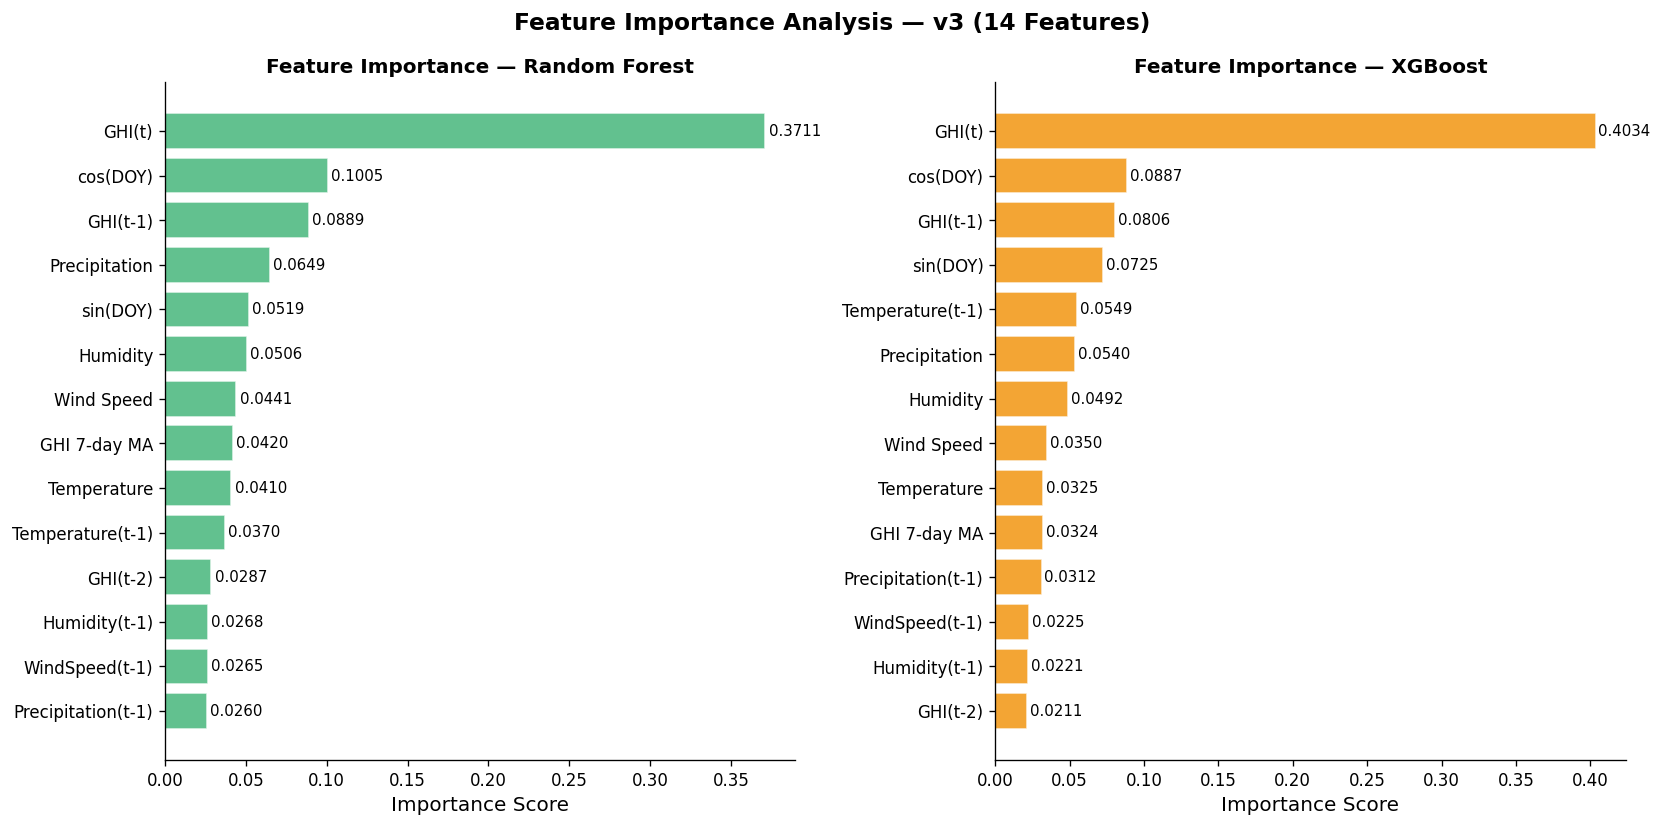

In [ ]:
# ─────────────────────────────────────────────────────────────────────────
# 12.1  Figure — RF vs XGBoost Feature Importance (side-by-side)
# ─────────────────────────────────────────────────────────────────────────
feat_labels = {
    # GHI features
    'GHI'                 : 'GHI(t)',
    'GHI_lag1'            : 'GHI(t-1)',
    'GHI_lag2'            : 'GHI(t-2)',
    'GHI_roll7'           : 'GHI 7-day MA',
    # Current-day weather
    'Temperature'         : 'Temperature',
    'Humidity'            : 'Humidity',
    'WindSpeed'           : 'Wind Speed',
    'Precipitation'       : 'Precipitation',
    # Weather lag features [NEW in v3]
    'Temperature_lag1'    : 'Temperature(t-1)',
    'Humidity_lag1'       : 'Humidity(t-1)',
    'WindSpeed_lag1'      : 'WindSpeed(t-1)',
    'Precipitation_lag1'  : 'Precipitation(t-1)',
    # Seasonal encoding
    'sin_doy'             : 'sin(DOY)',
    'cos_doy'             : 'cos(DOY)',
}

fig, axes = plt.subplots(1, 2, figsize=(14, 7))
for ax, (imp_series, model_name, color) in zip(axes, [
    (rf_importance,  'Random Forest', PALETTE[2]),
    (xgb_importance, 'XGBoost',       PALETTE[3]),
]):
    labels = [feat_labels[f] for f in imp_series.index]
    ax.barh(labels[::-1], imp_series.values[::-1], color=color, alpha=0.8, edgecolor='white')
    ax.set_title(f'Feature Importance — {model_name}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Importance Score')
    for i, v in enumerate(imp_series.values[::-1]):
        ax.text(v + 0.002, i, f'{v:.4f}', va='center', fontsize=9)

plt.suptitle('Feature Importance Analysis — v3 (14 Features)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/fig09_feature_importance.png')
plt.show()

In [ ]:
# ─────────────────────────────────────────────────────────────────────────
# 12.2  SHAP Analysis — XGBoost
#
# SHAP (SHapley Additive exPlanations) provides theoretically grounded,
# model-agnostic feature attribution. Each SHAP value quantifies the
# contribution of a feature to a single prediction, decomposing the
# prediction gap from the baseline (mean training output).
#
# TreeExplainer is the most efficient SHAP method for tree-based models.
# We use a subsample of the test set (500 rows) for speed.
# ─────────────────────────────────────────────────────────────────────────
print('Computing SHAP values for XGBoost... (may take ~30s)')

# Use a representative subsample for SHAP to keep runtime reasonable
np.random.seed(RANDOM_STATE)
shap_idx    = np.random.choice(len(X_test), size=min(500, len(X_test)), replace=False)
X_test_shap = X_test[shap_idx]

explainer   = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test_shap)

# Convert to DataFrame for readable labelling
X_test_shap_df = pd.DataFrame(X_test_shap, columns=FEATURES)
feature_names_readable = [feat_labels[f] for f in FEATURES]
X_test_shap_df.columns  = feature_names_readable
shap_values_df = pd.DataFrame(shap_values, columns=feature_names_readable)

print('✓ SHAP values computed.')

Computing SHAP values for XGBoost... (may take ~30s)
✓ SHAP values computed.


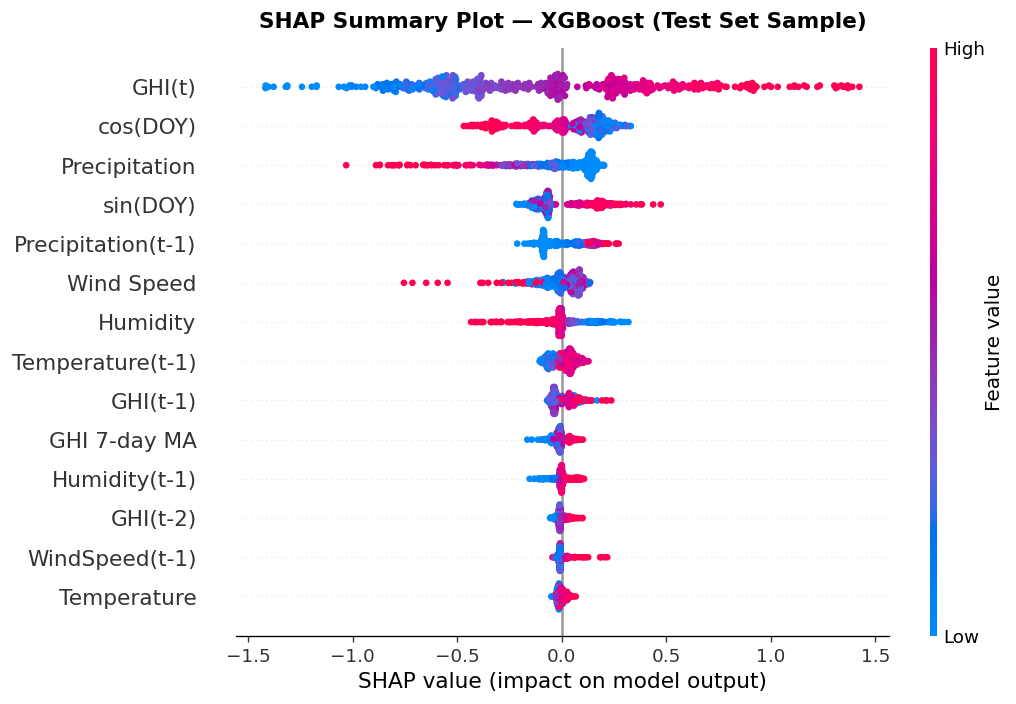

Saved → fig10_shap_summary.png


In [ ]:
# ─────────────────────────────────────────────────────────────────────────
# SHAP Summary Plot (Beeswarm)
# ─────────────────────────────────────────────────────────────────────────
plt.figure(figsize=(9, 6))
shap.summary_plot(
    shap_values,
    X_test_shap_df,
    feature_names=feature_names_readable,
    show=False,
    plot_size=(9, 6),
)
plt.title('SHAP Summary Plot — XGBoost (Test Set Sample)',
          fontsize=13, fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/fig10_shap_summary.png', bbox_inches='tight')
plt.show()
print('Saved → fig10_shap_summary.png')

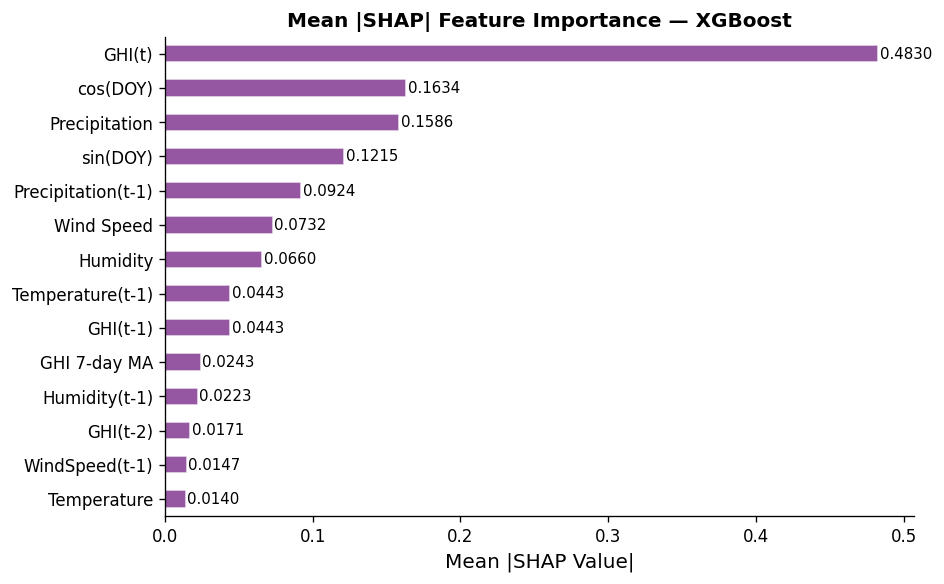

Saved → fig11_shap_bar.png


In [ ]:
# ─────────────────────────────────────────────────────────────────────────
# SHAP Bar Plot — Mean |SHAP| per feature
# ─────────────────────────────────────────────────────────────────────────
mean_abs_shap = np.abs(shap_values).mean(axis=0)
shap_bar_df   = pd.Series(mean_abs_shap, index=feature_names_readable).sort_values()

fig, ax = plt.subplots(figsize=(8, 5))
shap_bar_df.plot(kind='barh', ax=ax, color=PALETTE[4], alpha=0.8, edgecolor='white')
ax.set_title('Mean |SHAP| Feature Importance — XGBoost', fontsize=12, fontweight='bold')
ax.set_xlabel('Mean |SHAP Value|')
for i, v in enumerate(shap_bar_df.values):
    ax.text(v + 0.001, i, f'{v:.4f}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/fig11_shap_bar.png')
plt.show()
print('Saved → fig11_shap_bar.png')

## 📈 Section 13: Visualizations for Research Paper

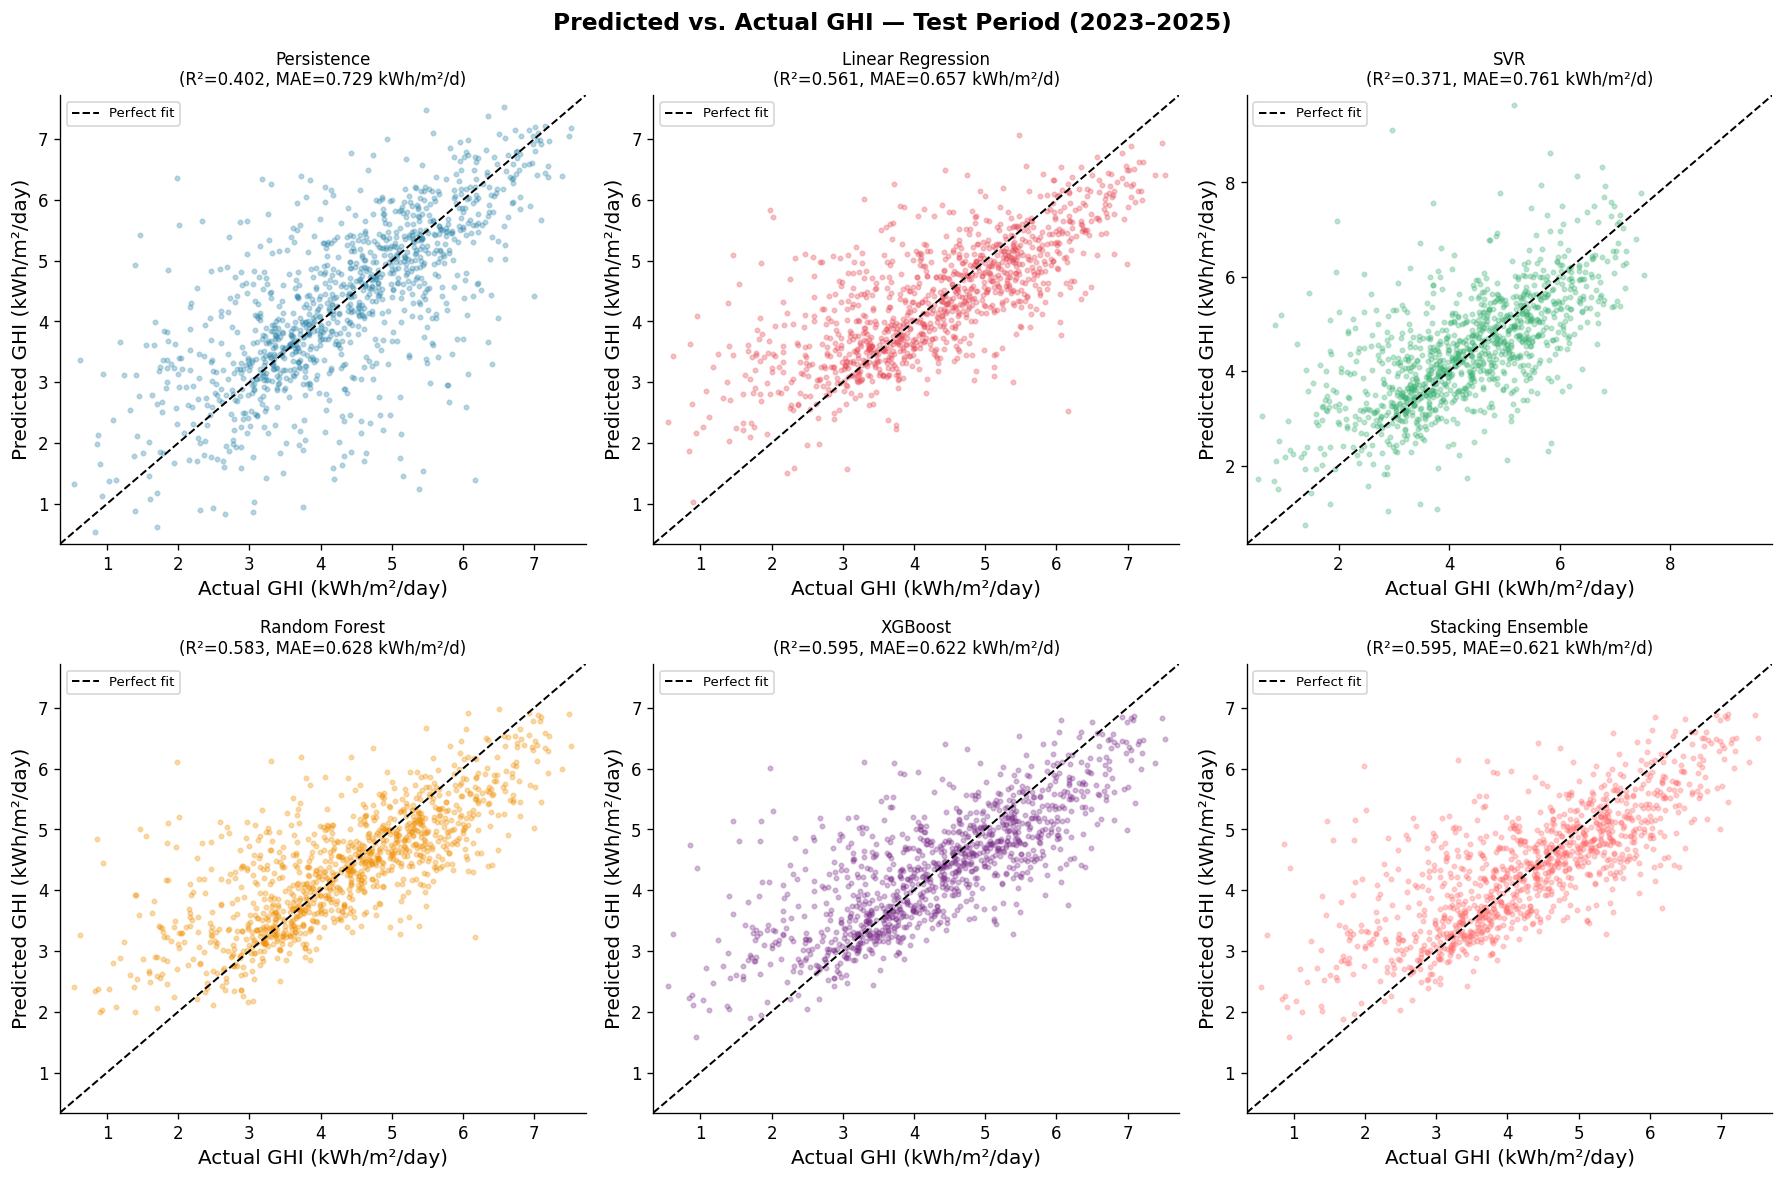

Saved → fig05_predicted_vs_actual_scatter.png


In [ ]:
# ─────────────────────────────────────────────────────────────────────────
# Figure — Predicted vs Actual Scatter (all 6 models)
# ─────────────────────────────────────────────────────────────────────────
model_names = ['Persistence', 'Linear Regression', 'SVR',
               'Random Forest', 'XGBoost', 'Stacking Ensemble']

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for ax, name, color in zip(axes, model_names, PALETTE):
    y_pred = predictions[name]
    ax.scatter(y_test, y_pred, alpha=0.3, s=7, color=color, rasterized=True)
    lim = [min(y_test.min(), y_pred.min()) - 0.2,
           max(y_test.max(), y_pred.max()) + 0.2]
    ax.plot(lim, lim, 'k--', linewidth=1.2, label='Perfect fit')
    r2  = results_df.loc[name, 'R²']
    mae = results_df.loc[name, 'MAE']
    ax.set_title(f'{name}\n(R²={r2:.3f}, MAE={mae:.3f} kWh/m²/d)', fontsize=10)
    ax.set_xlabel('Actual GHI (kWh/m²/day)')
    ax.set_ylabel('Predicted GHI (kWh/m²/day)')
    ax.set_xlim(lim); ax.set_ylim(lim)
    ax.legend(fontsize=8)

plt.suptitle('Predicted vs. Actual GHI — Test Period (2023–2025)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/fig05_predicted_vs_actual_scatter.png')
plt.show()
print('Saved → fig05_predicted_vs_actual_scatter.png')

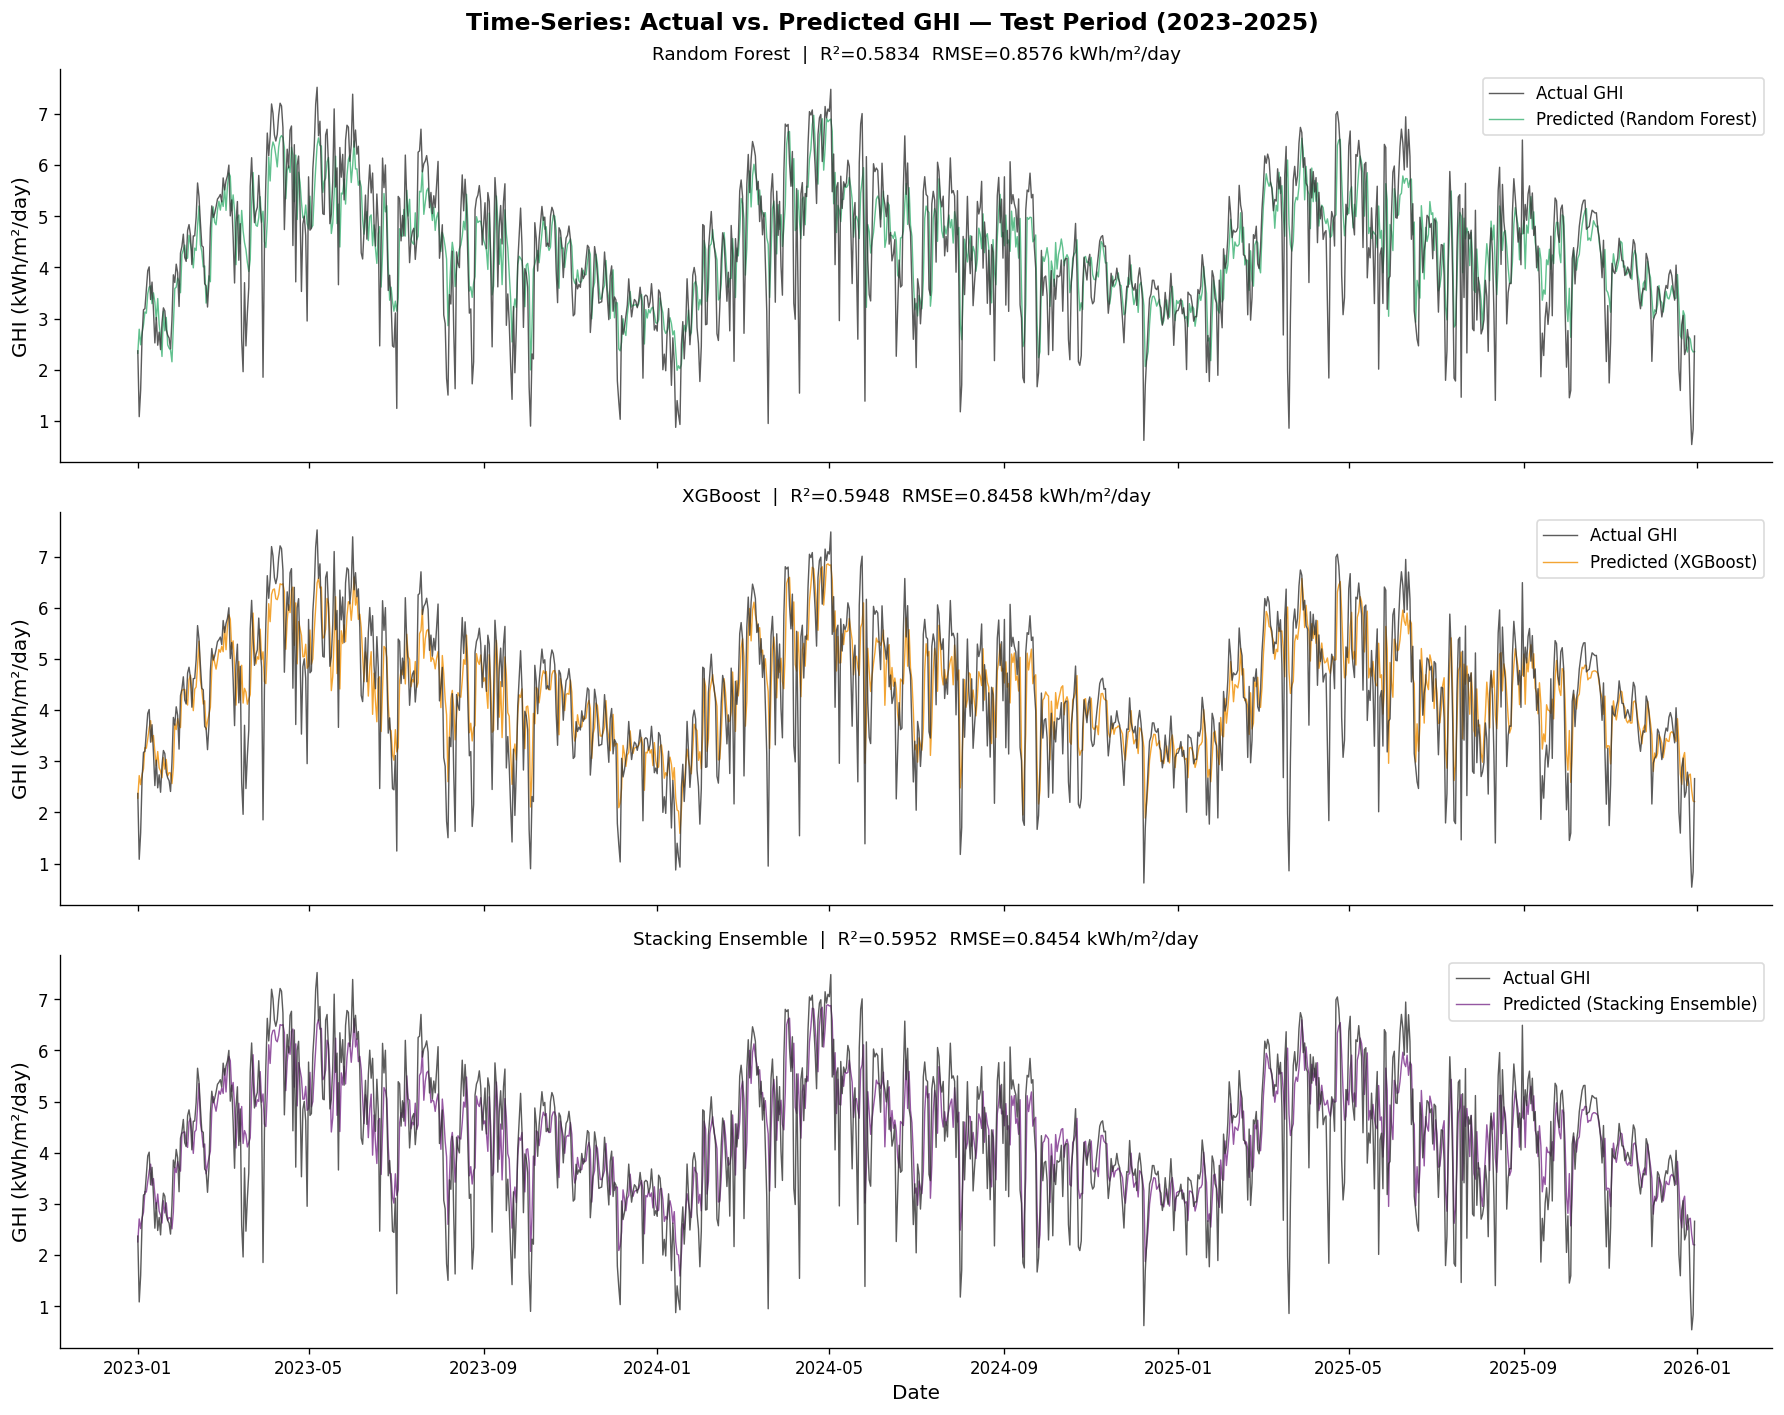

Saved → fig06_timeseries_comparison.png


In [ ]:
# ─────────────────────────────────────────────────────────────────────────
# Figure — Time-Series Comparison: Top 3 Models vs Actual
# ─────────────────────────────────────────────────────────────────────────
test_dates = test.index
top3 = [('Random Forest',   y_rf,    PALETTE[2]),
        ('XGBoost',          y_xgb,   PALETTE[3]),
        ('Stacking Ensemble', y_stack, PALETTE[4])]

fig, axes = plt.subplots(3, 1, figsize=(15, 12), sharex=True)
for ax, (name, y_pred, color) in zip(axes, top3):
    ax.plot(test_dates, y_test, color='#333333', linewidth=0.85,
            alpha=0.8, label='Actual GHI', zorder=3)
    ax.plot(test_dates, y_pred, color=color, linewidth=0.85,
            alpha=0.8, label=f'Predicted ({name})', zorder=2)
    r2   = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    ax.set_ylabel('GHI (kWh/m²/day)')
    ax.set_title(f'{name}  |  R²={r2:.4f}  RMSE={rmse:.4f} kWh/m²/day', fontsize=11)
    ax.legend(loc='upper right', framealpha=0.7)

axes[-1].set_xlabel('Date')
plt.suptitle('Time-Series: Actual vs. Predicted GHI — Test Period (2023–2025)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/fig06_timeseries_comparison.png')
plt.show()
print('Saved → fig06_timeseries_comparison.png')

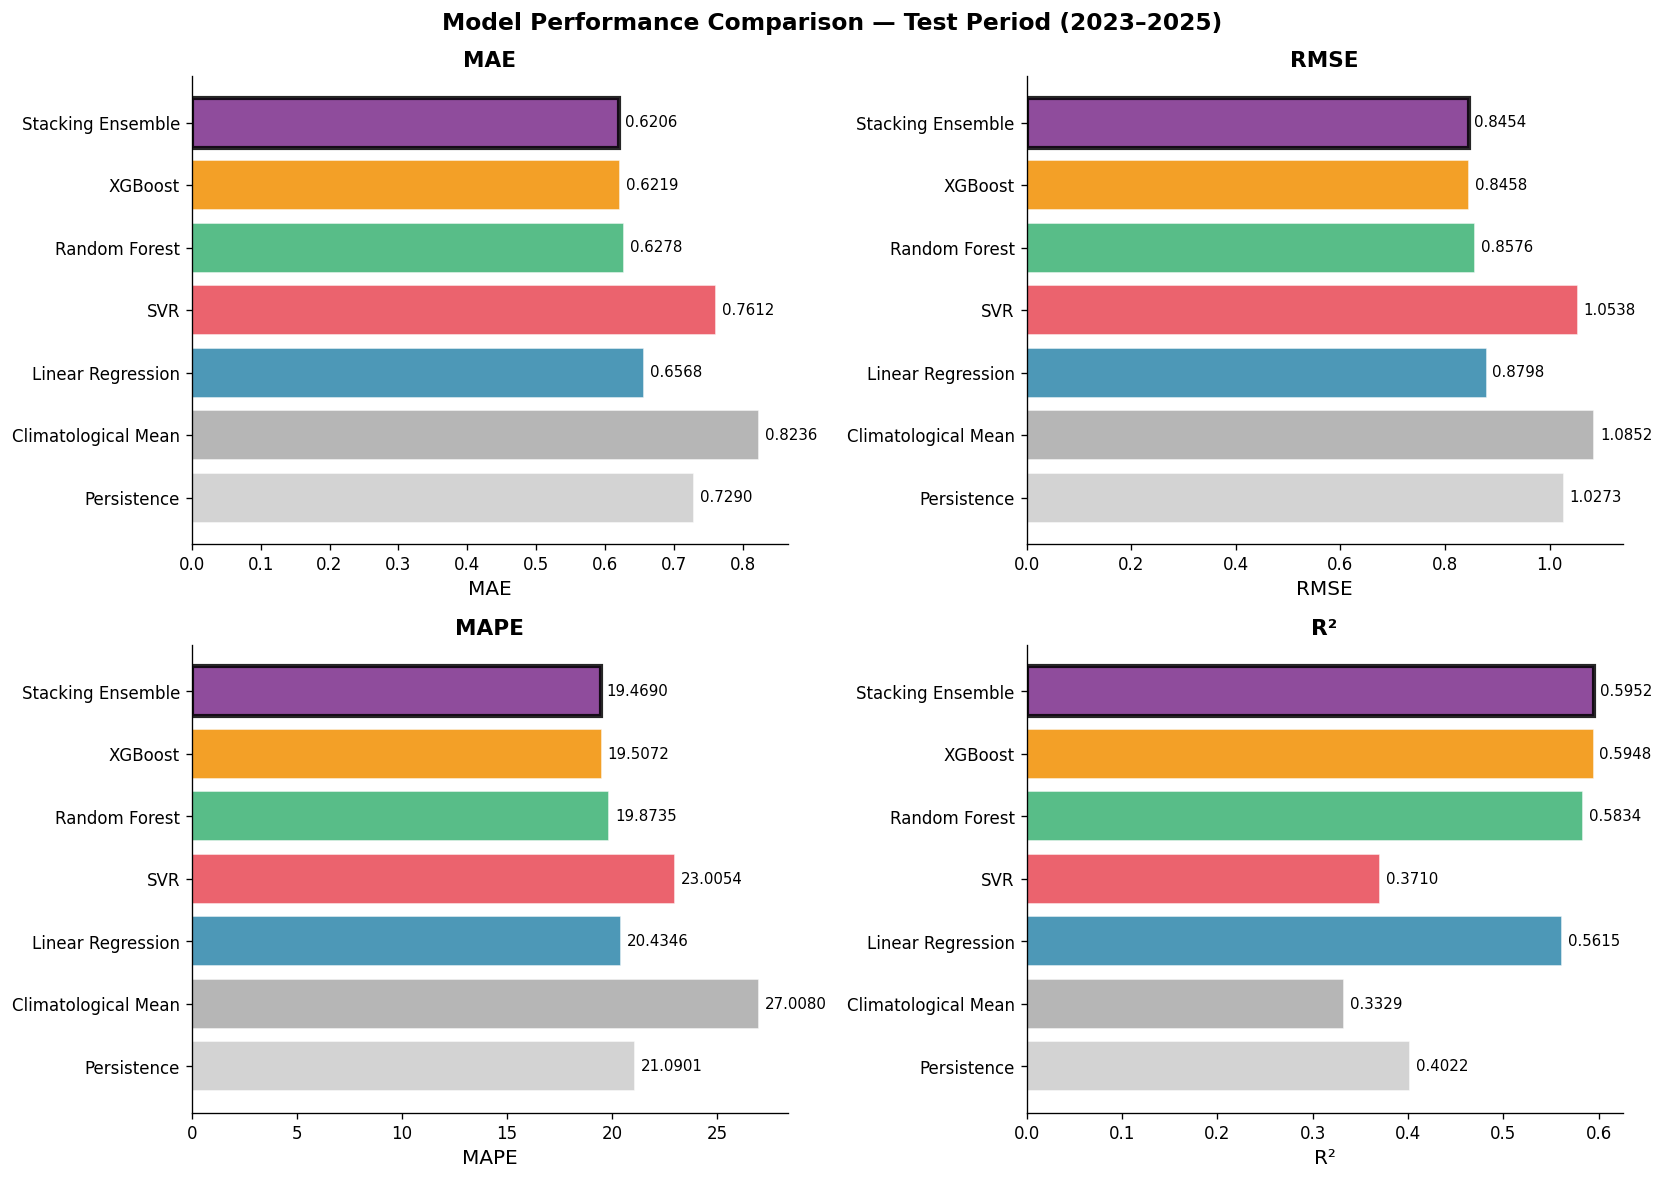

Saved → fig07_metrics_comparison.png


In [ ]:
# ─────────────────────────────────────────────────────────────────────────
# Figure — Model Metrics Comparison (horizontal bar charts)
# ─────────────────────────────────────────────────────────────────────────
all_models_ordered = ['Persistence', 'Climatological Mean', 'Linear Regression',
                      'SVR', 'Random Forest', 'XGBoost', 'Stacking Ensemble']
bar_colors = ['#cccccc', '#aaaaaa'] + PALETTE[:5]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, metric in zip(axes, ['MAE', 'RMSE', 'MAPE', 'R²']):
    vals = [results_df.loc[m, metric] for m in all_models_ordered]
    bars = ax.barh(all_models_ordered, vals, color=bar_colors, alpha=0.85, edgecolor='white')
    for bar, val in zip(bars, vals):
        ax.text(bar.get_width() + max(vals)*0.01, bar.get_y() + bar.get_height()/2,
                f'{val:.4f}', va='center', fontsize=9)
    best_idx = np.argmax(vals) if metric == 'R²' else np.argmin(vals)
    bars[best_idx].set_edgecolor('black')
    bars[best_idx].set_linewidth(2.5)
    ax.set_title(metric, fontsize=13, fontweight='bold')
    ax.set_xlabel(metric)

plt.suptitle('Model Performance Comparison — Test Period (2023–2025)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/fig07_metrics_comparison.png')
plt.show()
print('Saved → fig07_metrics_comparison.png')

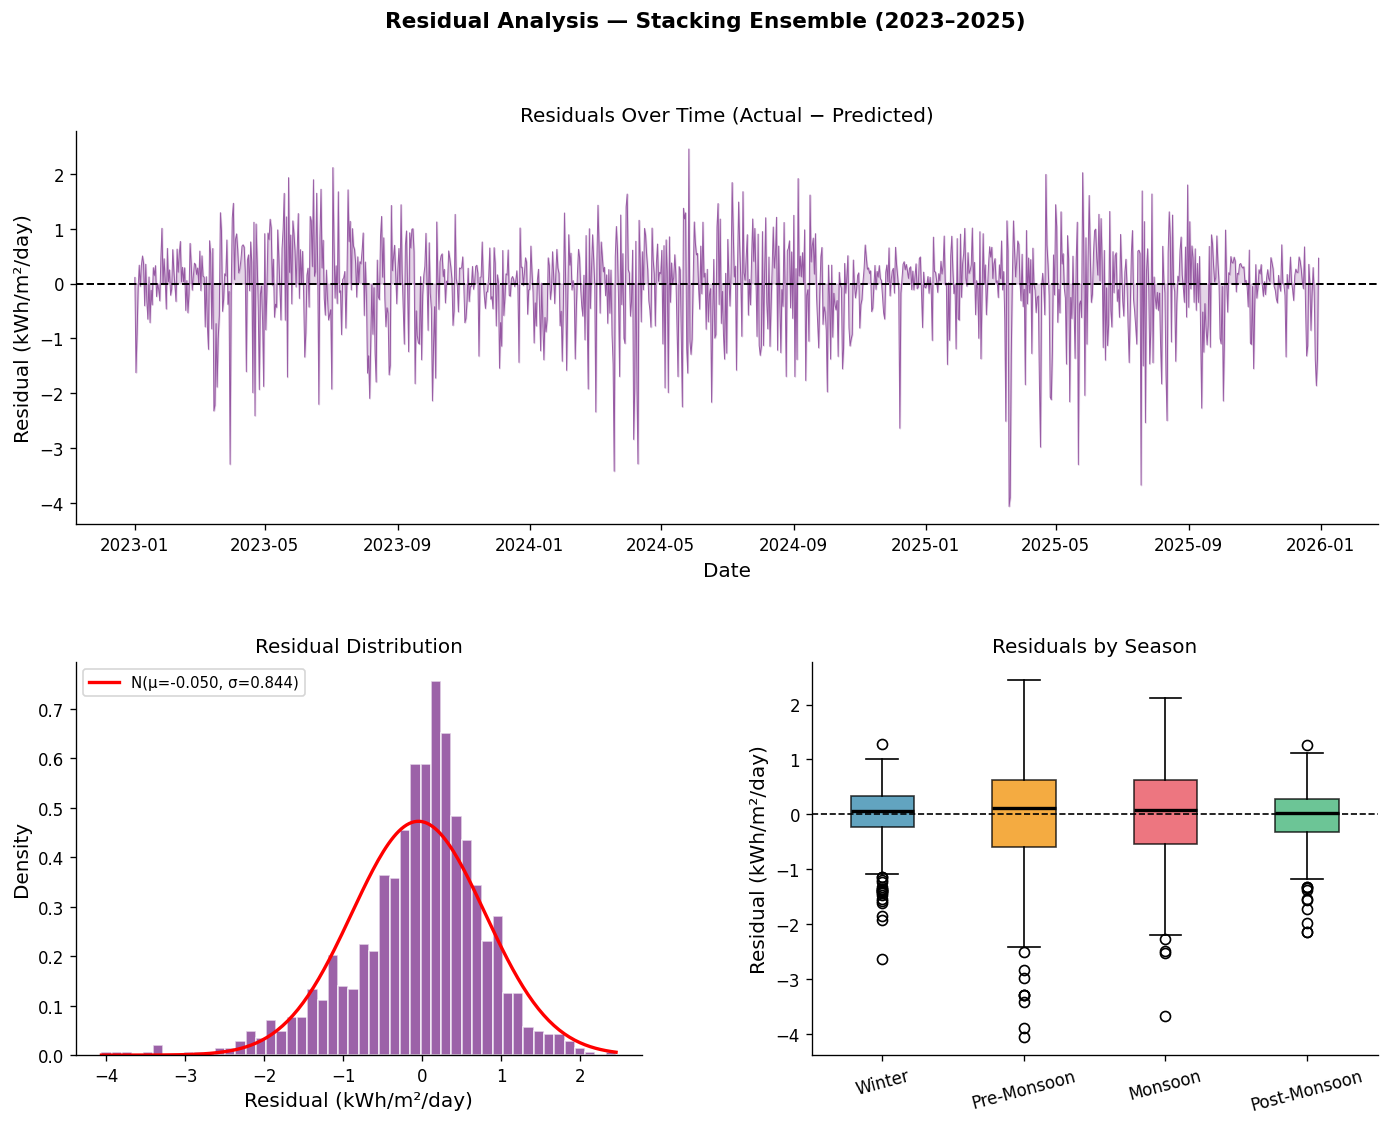

Saved → fig08_residual_analysis.png


In [ ]:
# ─────────────────────────────────────────────────────────────────────────
# Figure — Residual Analysis (Stacking Ensemble)
# ─────────────────────────────────────────────────────────────────────────
residuals = y_test - y_stack
test_res  = test.copy()
test_res['residual'] = residuals
test_res['Season']   = test_res.index.month.map(get_season)

fig = plt.figure(figsize=(14, 10))
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.35, wspace=0.3)

# Residuals over time
ax1 = fig.add_subplot(gs[0, :])
ax1.plot(test_dates, residuals, color=PALETTE[4], linewidth=0.6, alpha=0.7)
ax1.axhline(0, color='black', linestyle='--', linewidth=1.2)
ax1.fill_between(test_dates, residuals, 0, alpha=0.2, color=PALETTE[4])
ax1.set_title('Residuals Over Time (Actual − Predicted)', fontsize=12)
ax1.set_ylabel('Residual (kWh/m²/day)')
ax1.set_xlabel('Date')

# Residual histogram with normal fit
ax2 = fig.add_subplot(gs[1, 0])
mu, sigma = residuals.mean(), residuals.std()
ax2.hist(residuals, bins=50, color=PALETTE[4], alpha=0.75, edgecolor='white', density=True)
x_fit = np.linspace(residuals.min(), residuals.max(), 200)
ax2.plot(x_fit, stats.norm.pdf(x_fit, mu, sigma), 'r-', linewidth=2,
         label=f'N(μ={mu:.3f}, σ={sigma:.3f})')
ax2.set_title('Residual Distribution', fontsize=12)
ax2.set_xlabel('Residual (kWh/m²/day)')
ax2.set_ylabel('Density')
ax2.legend(fontsize=9)

# Box plot of residuals by season
ax3 = fig.add_subplot(gs[1, 1])
season_res = [test_res[test_res['Season'] == s]['residual'].values for s in SEASON_ORDER]
bp = ax3.boxplot(season_res, labels=SEASON_ORDER, patch_artist=True, notch=False,
                 medianprops=dict(color='black', linewidth=2))
for patch, s in zip(bp['boxes'], SEASON_ORDER):
    patch.set_facecolor(SEASON_COLORS[s]); patch.set_alpha(0.75)
ax3.axhline(0, color='black', linestyle='--', linewidth=1)
ax3.set_title('Residuals by Season', fontsize=12)
ax3.set_ylabel('Residual (kWh/m²/day)')
ax3.tick_params(axis='x', rotation=15)

plt.suptitle('Residual Analysis — Stacking Ensemble (2023–2025)',
             fontsize=13, fontweight='bold')
plt.savefig(f'{OUTPUT_DIR}/fig08_residual_analysis.png')
plt.show()
print('Saved → fig08_residual_analysis.png')

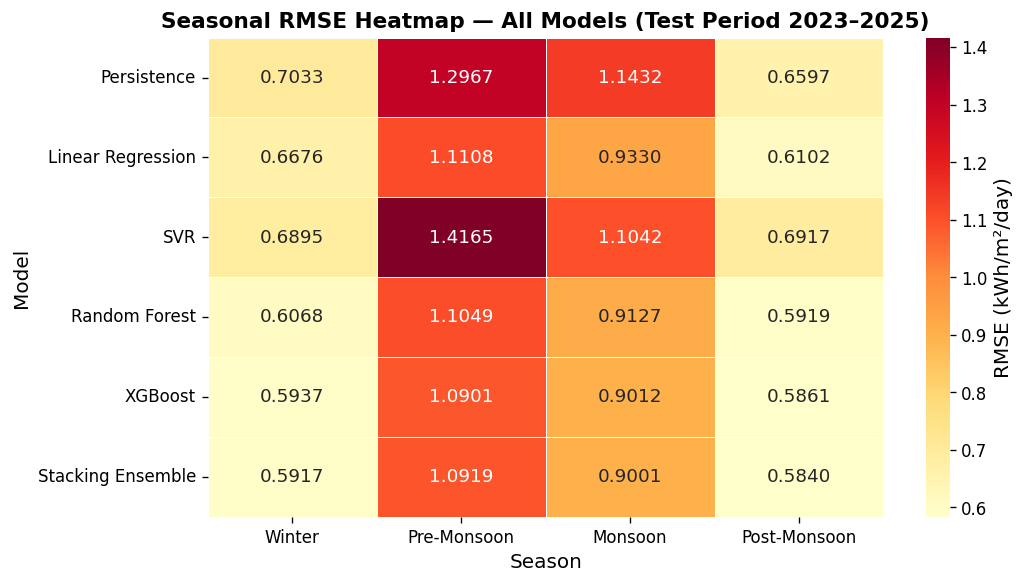

Saved → fig12_seasonal_rmse_heatmap.png


In [ ]:
# ─────────────────────────────────────────────────────────────────────────
# Figure — Seasonal RMSE Heatmap (all models)
# ─────────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))
sns.heatmap(seasonal_rmse_df, annot=True, fmt='.4f', cmap='YlOrRd',
            linewidths=0.5, ax=ax, cbar_kws={'label': 'RMSE (kWh/m²/day)'})
ax.set_title('Seasonal RMSE Heatmap — All Models (Test Period 2023–2025)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Season')
ax.set_ylabel('Model')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/fig12_seasonal_rmse_heatmap.png')
plt.show()
print('Saved → fig12_seasonal_rmse_heatmap.png')

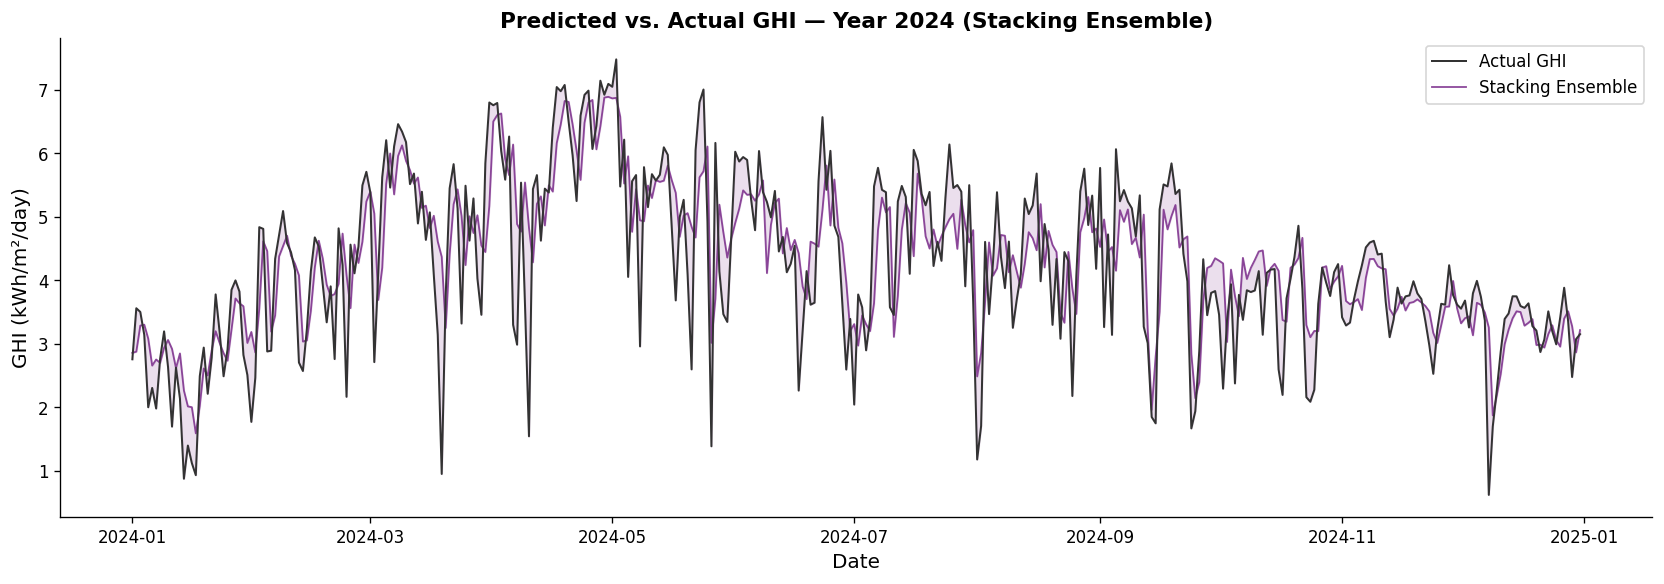

Saved → fig13_year2024_zoom.png


In [ ]:
# ─────────────────────────────────────────────────────────────────────────
# Figure — Zoomed View: Year 2024 (Stacking Ensemble)
# ─────────────────────────────────────────────────────────────────────────
mask_2024   = (test.index.year == 2024)
dates_2024  = test.index[mask_2024]
actual_2024 = y_test[mask_2024]
pred_2024   = y_stack[mask_2024]

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(dates_2024, actual_2024, color='#333333', linewidth=1.2, label='Actual GHI', zorder=3)
ax.plot(dates_2024, pred_2024, color=PALETTE[4], linewidth=1.1,
        alpha=0.85, label='Stacking Ensemble', zorder=2)
ax.fill_between(dates_2024, actual_2024, pred_2024, alpha=0.15, color=PALETTE[4])
ax.set_title('Predicted vs. Actual GHI — Year 2024 (Stacking Ensemble)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('GHI (kWh/m²/day)')
ax.legend()
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/fig13_year2024_zoom.png')
plt.show()
print('Saved → fig13_year2024_zoom.png')

## 💾 Section 14: Export Results & Download as ZIP

In [ ]:
import shutil
from google.colab import files as colab_files

# ── Save all result tables ────────────────────────────────────────────────
results_df.to_csv(f'{OUTPUT_DIR}/table1_model_comparison.csv')
seasonal_detail_df.to_csv(f'{OUTPUT_DIR}/table2_seasonal_metrics_stacking.csv')
seasonal_rmse_df.to_csv(f'{OUTPUT_DIR}/table3_seasonal_rmse_all_models.csv')

# Feature importance tables
feat_labels = {
    'GHI':'GHI(t)', 'GHI_lag1':'GHI(t-1)', 'GHI_lag2':'GHI(t-2)',
    'GHI_roll7':'GHI 7-day MA',
    'Temperature':'Temperature', 'Humidity':'Humidity',
    'WindSpeed':'Wind Speed', 'Precipitation':'Precipitation',
    'Temperature_lag1':'Temperature(t-1)', 'Humidity_lag1':'Humidity(t-1)',
    'WindSpeed_lag1':'WindSpeed(t-1)', 'Precipitation_lag1':'Precipitation(t-1)',
    'sin_doy':'sin(DOY)', 'cos_doy':'cos(DOY)',
}
rf_importance.rename(index=feat_labels).round(4).to_csv(
    f'{OUTPUT_DIR}/table4_rf_feature_importance.csv', header=['Importance'])
xgb_importance.rename(index=feat_labels).round(4).to_csv(
    f'{OUTPUT_DIR}/table5_xgb_feature_importance.csv', header=['Importance'])

# SHAP mean |values|
feature_names_readable = [feat_labels.get(f, f) for f in FEATURES]
mean_shap_df = pd.Series(mean_abs_shap, index=feature_names_readable).sort_values(ascending=False)
mean_shap_df.round(4).to_csv(f'{OUTPUT_DIR}/table6_shap_mean_abs.csv', header=['Mean|SHAP|'])

# All predictions
pred_export = test[[TARGET] + FEATURES].copy().rename(columns={TARGET: 'GHI_actual'})
for name, y_pred in predictions.items():
    pred_export[name.replace(' ','_')] = y_pred
pred_export.to_csv(f'{OUTPUT_DIR}/predictions_all_models.csv')

# Descriptive statistics
df_model[['GHI','Temperature','Humidity','WindSpeed','Precipitation']].describe().T.round(4).to_csv(
    f'{OUTPUT_DIR}/table0_descriptive_statistics.csv')

# Best hyperparameters
pd.DataFrame([rf_search.best_params_]).to_csv(
    f'{OUTPUT_DIR}/best_params_rf.csv', index=False)
pd.DataFrame([xgb_search.best_params_]).to_csv(
    f'{OUTPUT_DIR}/best_params_xgb.csv', index=False)

print(f'✅ All CSVs saved to {OUTPUT_DIR}/')
print('\nFiles saved:')
for fn in sorted(os.listdir(OUTPUT_DIR)):
    print(f'  {fn}')

# ── Zip everything and download ───────────────────────────────────────────
zip_path = '/content/solar_forecasting_v3_results'
shutil.make_archive(zip_path, 'zip', OUTPUT_DIR)
colab_files.download(f'{zip_path}.zip')
print('\n✅ solar_forecasting_v3_results.zip downloaded to your computer.')

✅ All CSVs saved to /content/solar_outputs_v3/

Files saved:
  best_params_rf.csv
  best_params_xgb.csv
  fig01_time_series_overview.png
  fig02_seasonal_ghi_distribution.png
  fig03_correlation_heatmap.png
  fig04_annual_ghi_trend.png
  fig05_predicted_vs_actual_scatter.png
  fig06_timeseries_comparison.png
  fig07_metrics_comparison.png
  fig08_residual_analysis.png
  fig09_feature_importance.png
  fig10_shap_summary.png
  fig11_shap_bar.png
  fig12_seasonal_rmse_heatmap.png
  fig13_year2024_zoom.png
  predictions_all_models.csv
  table0_descriptive_statistics.csv
  table1_model_comparison.csv
  table2_seasonal_metrics_stacking.csv
  table3_seasonal_rmse_all_models.csv
  table4_rf_feature_importance.csv
  table5_xgb_feature_importance.csv
  table6_shap_mean_abs.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✅ solar_forecasting_v3_results.zip downloaded to your computer.


In [ ]:
# ─────────────────────────────────────────────────────────────────────────
# Final Summary Print
# ─────────────────────────────────────────────────────────────────────────
print('=' * 65)
print('FINAL MODEL COMPARISON — Test Period (2023–2025)')
print('=' * 65)
print(results_df.to_string())

print('\n' + '=' * 65)
print('SEASONAL METRICS — Stacking Ensemble')
print('=' * 65)
print(seasonal_detail_df.to_string())

best = results_df.loc['Stacking Ensemble']
base = results_df.loc['Persistence']
print('\n' + '=' * 65)
print('BEST MODEL: Stacking Ensemble')
print(f'  MAE  : {best["MAE"]:.4f} kWh/m²/day  '
      f'(↓{(base["MAE"]-best["MAE"])/base["MAE"]*100:.1f}% vs Persistence)')
print(f'  RMSE : {best["RMSE"]:.4f} kWh/m²/day  '
      f'(↓{(base["RMSE"]-best["RMSE"])/base["RMSE"]*100:.1f}% vs Persistence)')
print(f'  MAPE : {best["MAPE"]:.4f}%')
print(f'  R²   : {best["R²"]:.4f}')
print('=' * 65)

FINAL MODEL COMPARISON — Test Period (2023–2025)
                        MAE    RMSE     MAPE      R²
Model                                               
Persistence          0.7290  1.0273  21.0901  0.4022
Climatological Mean  0.8236  1.0852  27.0080  0.3329
Linear Regression    0.6568  0.8798  20.4346  0.5615
SVR                  0.7612  1.0538  23.0054  0.3710
Random Forest        0.6278  0.8576  19.8735  0.5834
XGBoost              0.6219  0.8458  19.5072  0.5948
Stacking Ensemble    0.6206  0.8454  19.4690  0.5952

SEASONAL METRICS — Stacking Ensemble
                 MAE    RMSE     MAPE      R²    N
Model                                             
Winter        0.4299  0.5917  18.6939  0.6449  270
Pre-Monsoon   0.8155  1.0919  22.6015  0.2911  276
Monsoon       0.7174  0.9001  20.3573  0.4722  366
Post-Monsoon  0.4143  0.5840  14.1114  0.5000  183

BEST MODEL: Stacking Ensemble
  MAE  : 0.6206 kWh/m²/day  (↓14.9% vs Persistence)
  RMSE : 0.8454 kWh/m²/day  (↓17.7% vs Persiste